## Business Goal

- The business goal of our project is to reduce financial losses caused by fraudulent meter manipulations for the Tunisian Company of Electricity and Gas (STEG). 

### Importing the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

from sklearn import set_config
set_config(transform_output='pandas')

from datetime import datetime


## Loading the Data

In [2]:

client_data_train = pd.read_csv('data/train/client_train.csv')
invoice_data_train = pd.read_csv('data/train/invoice_train.csv')

In [3]:
client_data_train.shape

(135493, 6)

In [4]:
invoice_data_train.shape

(4476749, 16)

In [5]:
client_data_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [6]:
invoice_data_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [7]:
client_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [8]:
invoice_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [9]:
client_data_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [10]:
invoice_data_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [11]:
client_data_train.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [12]:
invoice_data_train.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [13]:
df = pd.merge(client_data_train, invoice_data_train, on='client_id', how='inner')


In [14]:
df.shape

(4476749, 21)

In [15]:
df.isnull().sum()

disrict                 0
client_id               0
client_catg             0
region                  0
creation_date           0
target                  0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [16]:
df.duplicated().sum()

11

In [17]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.head(13)

,disrict,client_id,client_catg,region,creation_date,target,invoice_date,tarif_type,counter_number,counter_statue,...,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951893,60,train_Client_125864,11,101,29/12/1998,0.0,2011-12-12,11,101545,5,...,6,1,0,0,0,0,13680,13680,2,ELEC
1755798,62,train_Client_25894,11,301,16/06/1995,0.0,2010-07-13,40,6986740,5,...,6,1,0,0,0,0,0,0,2,GAZ
2137999,60,train_Client_3636,11,101,21/11/1988,0.0,2012-01-18,40,312650,5,...,6,1,0,0,0,0,623,623,2,GAZ
2163374,60,train_Client_37069,11,101,09/03/1990,0.0,2010-10-11,11,5284,5,...,6,1,0,0,0,0,99429,99429,2,ELEC
2433919,60,train_Client_44407,11,101,15/06/1989,1.0,2008-02-28,11,66921,5,...,6,1,0,0,0,0,0,0,2,ELEC
2805729,60,train_Client_54609,11,101,16/02/1994,0.0,2010-04-06,11,200912,5,...,6,1,0,0,0,0,0,0,2,ELEC
3260191,63,train_Client_66981,51,313,20/11/1996,1.0,2006-07-17,11,132701,5,...,6,1,0,0,0,0,5946,5946,2,ELEC
3260198,63,train_Client_66981,51,313,20/11/1996,1.0,2006-07-17,11,132701,5,...,6,1,0,0,0,0,5946,5946,2,ELEC
3394719,62,train_Client_7066,11,304,12/04/2013,0.0,2014-10-28,40,4463323,5,...,6,1,0,0,0,0,80,80,2,GAZ
3462929,60,train_Client_72519,11,101,03/06/1982,0.0,2013-01-21,11,246464,5,...,6,1,0,0,0,0,2954,2954,2,ELEC


In [18]:
duplicates_based_on_client_id = df.duplicated(subset=['client_id'])
duplicates_based_on_client_id.sum()

4341256

In [19]:
df.nunique()

disrict                      4
client_id               135493
client_catg                  3
region                      25
creation_date             8088
target                       2
invoice_date              8275
tarif_type                  17
counter_number          201893
counter_statue              16
counter_code                42
reading_remarque             8
counter_coefficient         16
consommation_level_1      8295
consommation_level_2     12576
consommation_level_3      2253
consommation_level_4     12075
old_index               155648
new_index               157980
months_number             1370
counter_type                 2
dtype: int64

In [20]:
df.value_counts()

disrict  client_id           client_catg  region  creation_date  target  invoice_date  tarif_type  counter_number  counter_statue  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number  counter_type
63       train_Client_66981  51           313     20/11/1996     1.0     2006-07-17    11          132701          5               420           6                 1                    0                     0                     0                     0                     5946       5946       2              ELEC            3
60       train_Client_37069  11           101     09/03/1990     0.0     2010-10-11    11          5284            5               413           6                 1                    0                     0                     0                     0                     99429      99429      2              ELEC            2
62       train_Client_70

In [21]:
df_no_duplicates = df.drop_duplicates()

In [22]:
df_no_duplicates.shape

(4476738, 21)

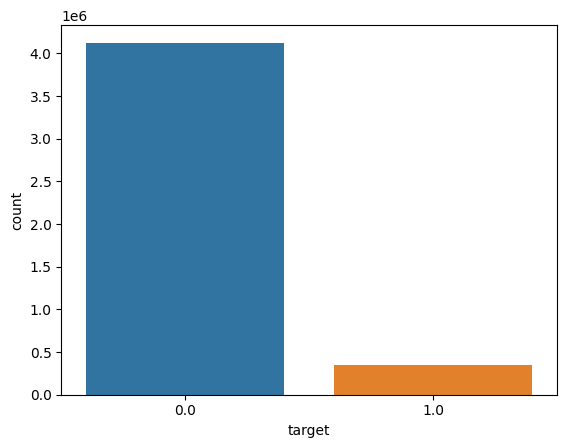

In [23]:
sns.countplot(x='target', data=df_no_duplicates)
plt.show()

In [24]:
df_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476738 entries, 0 to 4476748
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   disrict               int64  
 1   client_id             object 
 2   client_catg           int64  
 3   region                int64  
 4   creation_date         object 
 5   target                float64
 6   invoice_date          object 
 7   tarif_type            int64  
 8   counter_number        int64  
 9   counter_statue        object 
 10  counter_code          int64  
 11  reading_remarque      int64  
 12  counter_coefficient   int64  
 13  consommation_level_1  int64  
 14  consommation_level_2  int64  
 15  consommation_level_3  int64  
 16  consommation_level_4  int64  
 17  old_index             int64  
 18  new_index             int64  
 19  months_number         int64  
 20  counter_type          object 
dtypes: float64(1), int64(15), object(5)
memory usage: 751.4+ MB


In [25]:
df_no_duplicates.describe()

,disrict,client_catg,region,target,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06
mean,6.348247e+01,1.194379e+01,2.103584e+02,7.887641e-02,2.012804e+01,1.230590e+11,1.724882e+02,7.321705e+00,1.003040e+00,4.109805e+02,1.093227e+02,2.030625e+01,5.292601e+01,1.776701e+04,1.834972e+04,4.483105e+01
std,3.273404e+00,6.022374e+00,1.035828e+02,2.695458e-01,1.347256e+01,1.657269e+12,1.338869e+02,1.571655e+00,3.083470e-01,7.573087e+02,1.220125e+03,1.574241e+02,8.754735e+02,4.036695e+04,4.095323e+04,3.128339e+03
min,6.000000e+01,1.100000e+01,1.010000e+02,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.200000e+01,1.100000e+01,1.030000e+02,0.000000e+00,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,6.200000e+01,1.100000e+01,3.010000e+02,0.000000e+00,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,6.300000e+01,1.100000e+01,3.090000e+02,0.000000e+00,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,6.900000e+01,5.100000e+01,3.990000e+02,1.000000e+00,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [26]:
df_no_duplicates.isnull().sum()

disrict                 0
client_id               0
client_catg             0
region                  0
creation_date           0
target                  0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [27]:
df_no_duplicates.duplicated().sum()

0

In [28]:
df_no_duplicates['target'].value_counts()

target
0.0    4123629
1.0     353109
Name: count, dtype: int64

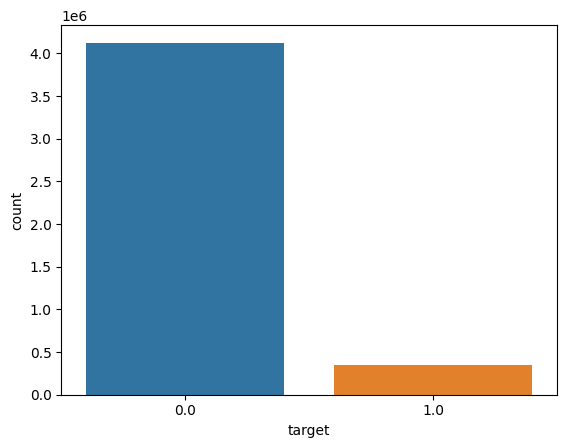

In [29]:
sns.countplot(x='target', data=df_no_duplicates)
plt.show()

In [30]:
X = df_no_duplicates.drop(columns=['target'], axis=1)
y = df_no_duplicates['target']

In [31]:
df_no_duplicates.to_csv('STEG.csv', index=False)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [33]:
# train dataframe shape
X_train.shape, y_train.shape

((3581390, 20), (3581390,))

In [34]:
y_train.value_counts(normalize=True)

target
0.0    0.921124
1.0    0.078876
Name: proportion, dtype: float64

In [35]:
# test dataframe shape
X_test.shape, y_test.shape

((895348, 20), (895348,))

In [36]:
y_test.value_counts(normalize=True)

target
0.0    0.921123
1.0    0.078877
Name: proportion, dtype: float64

In [37]:
X_train.duplicated().sum()

0

In [38]:
X_test.duplicated().sum()

0

In [39]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3581390 entries, 3661429 to 1143694
Data columns (total 20 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   disrict               int64 
 1   client_id             object
 2   client_catg           int64 
 3   region                int64 
 4   creation_date         object
 5   invoice_date          object
 6   tarif_type            int64 
 7   counter_number        int64 
 8   counter_statue        object
 9   counter_code          int64 
 10  reading_remarque      int64 
 11  counter_coefficient   int64 
 12  consommation_level_1  int64 
 13  consommation_level_2  int64 
 14  consommation_level_3  int64 
 15  consommation_level_4  int64 
 16  old_index             int64 
 17  new_index             int64 
 18  months_number         int64 
 19  counter_type          object
dtypes: int64(15), object(5)
memory usage: 573.8+ MB


In [40]:
X_train.describe()

,disrict,client_catg,region,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06,3.581390e+06
mean,6.348371e+01,1.194227e+01,2.103301e+02,2.013313e+01,1.227642e+11,1.724279e+02,7.321529e+00,1.003024e+00,4.109425e+02,1.095864e+02,2.024594e+01,5.305447e+01,1.777400e+04,1.835567e+04,4.384436e+01
std,3.274172e+00,6.017523e+00,1.035835e+02,1.347465e+01,1.654956e+12,1.338803e+02,1.519740e+00,3.082906e-01,7.961973e+02,1.299030e+03,1.530641e+02,8.925410e+02,4.045629e+04,4.103415e+04,3.050954e+03
min,6.000000e+01,1.100000e+01,1.010000e+02,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.200000e+01,1.100000e+01,1.030000e+02,1.100000e+01,1.211400e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.790000e+03,2.055000e+03,4.000000e+00
50%,6.200000e+01,1.100000e+01,3.010000e+02,1.100000e+01,4.945980e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.683000e+03,8.185000e+03,4.000000e+00
75%,6.300000e+01,1.100000e+01,3.090000e+02,4.000000e+01,1.115309e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.165400e+04,2.233800e+04,4.000000e+00
max,6.900000e+01,5.100000e+01,3.990000e+02,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.721031e+06,2.800280e+06,6.366240e+05


In [41]:
X_train.isnull().sum()

disrict                 0
client_id               0
client_catg             0
region                  0
creation_date           0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

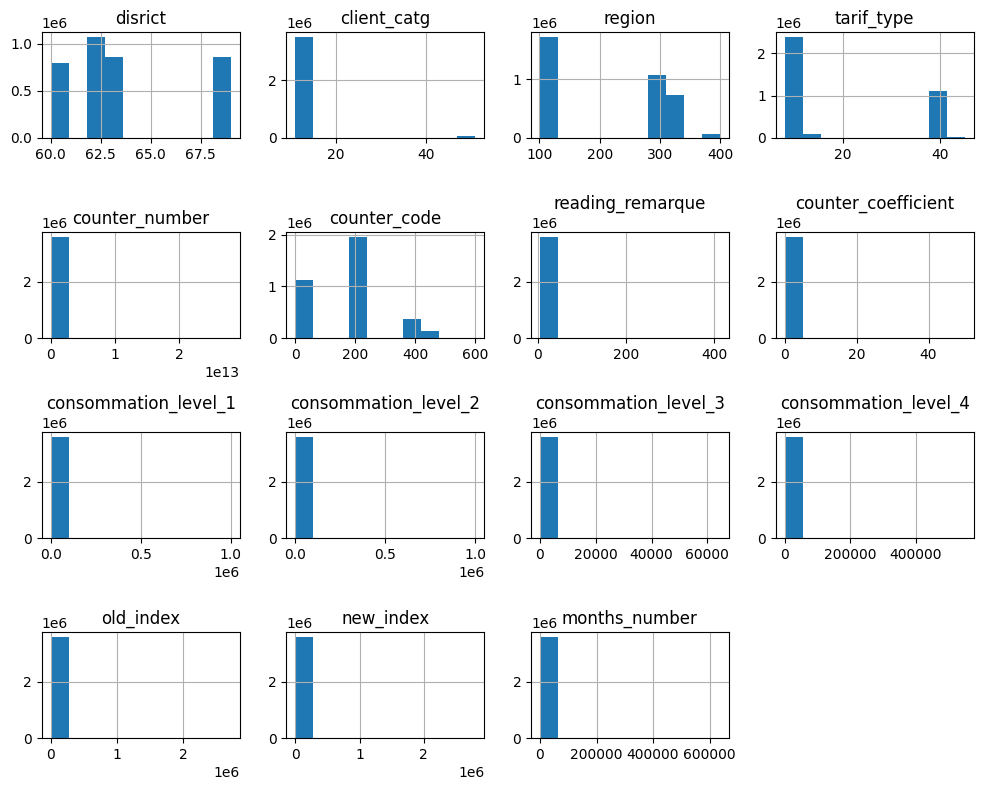

In [42]:
X_train.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

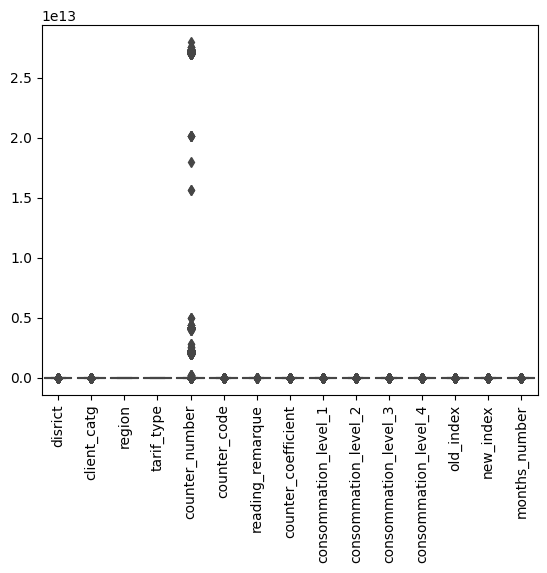

In [43]:
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [44]:
categorical_cols = ['disrict', 'client_catg', 'region', 'tarif_type', 'counter_statue', 'counter_type']
categorical_data = X_train[categorical_cols]
categorical_data.head()

,disrict,client_catg,region,tarif_type,counter_statue,counter_type
3661429,60,11,101,10,0,ELEC
4183240,62,11,301,40,0,GAZ
932772,62,11,310,40,0,GAZ
4255522,69,11,103,40,0,GAZ
914999,60,11,101,11,0,ELEC


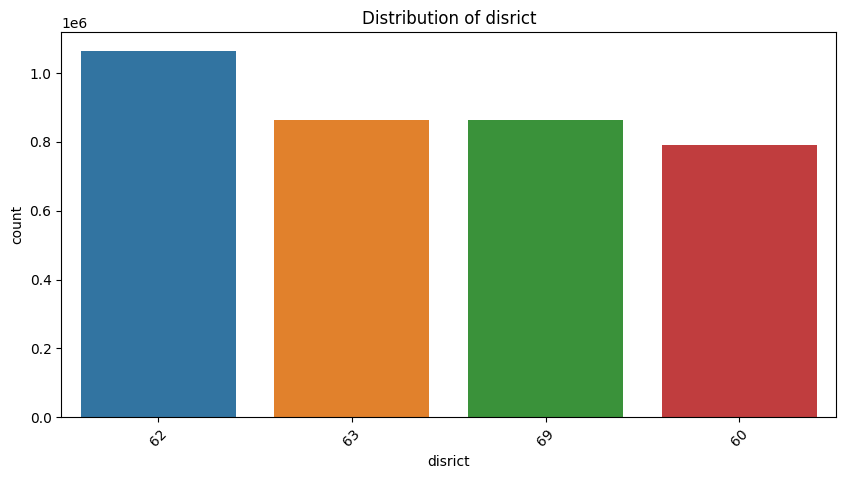

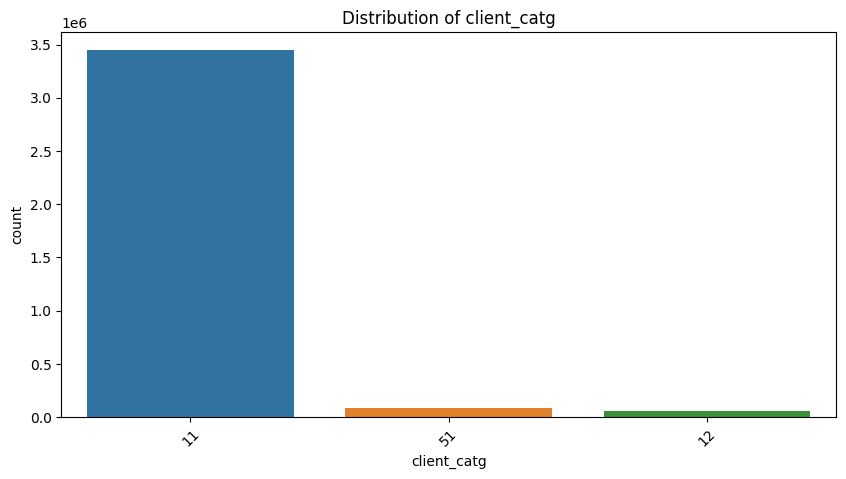

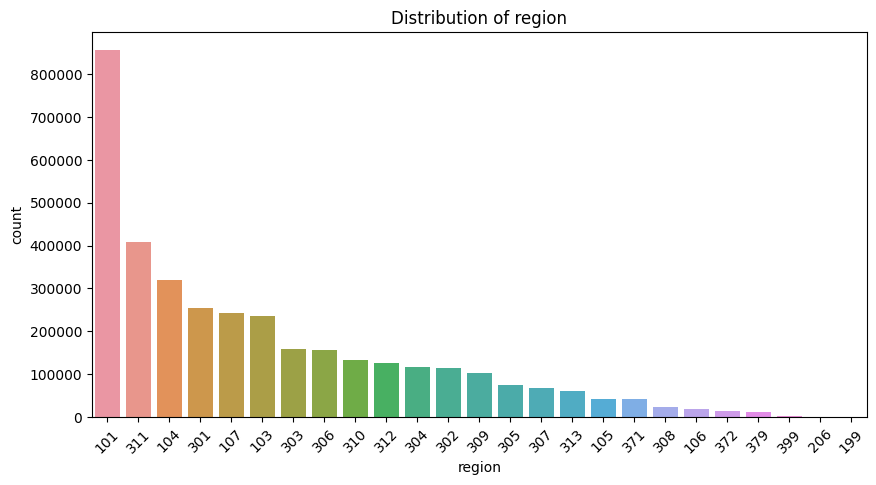

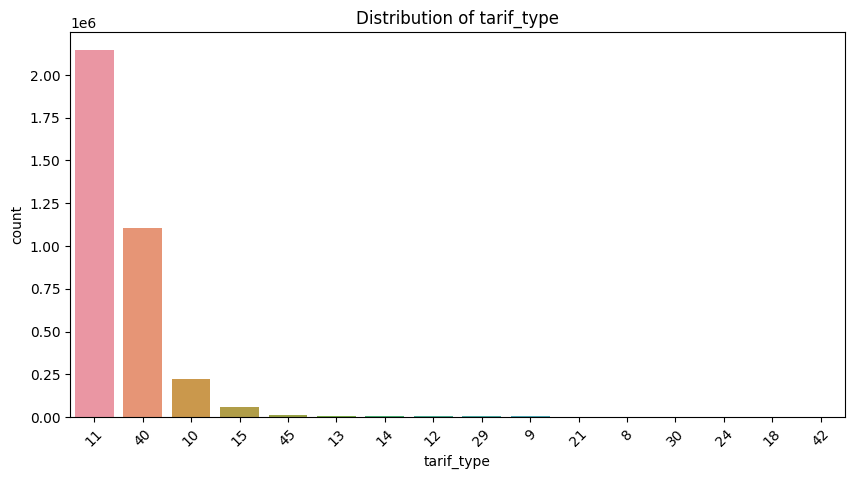

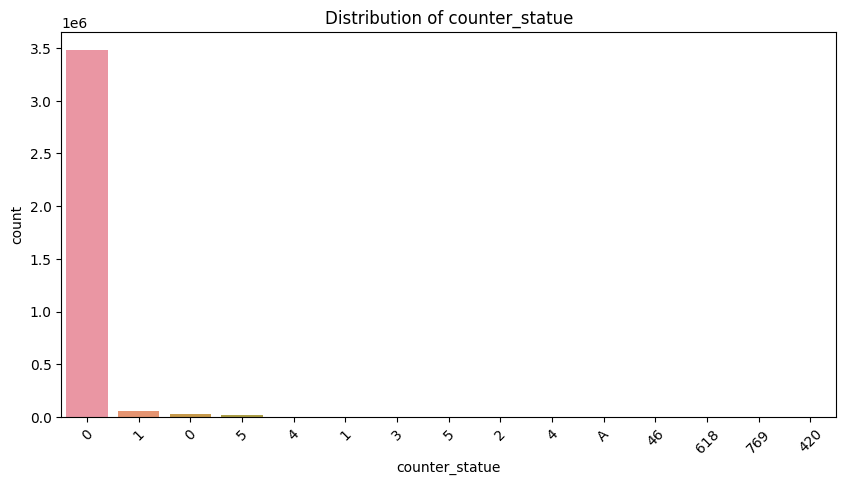

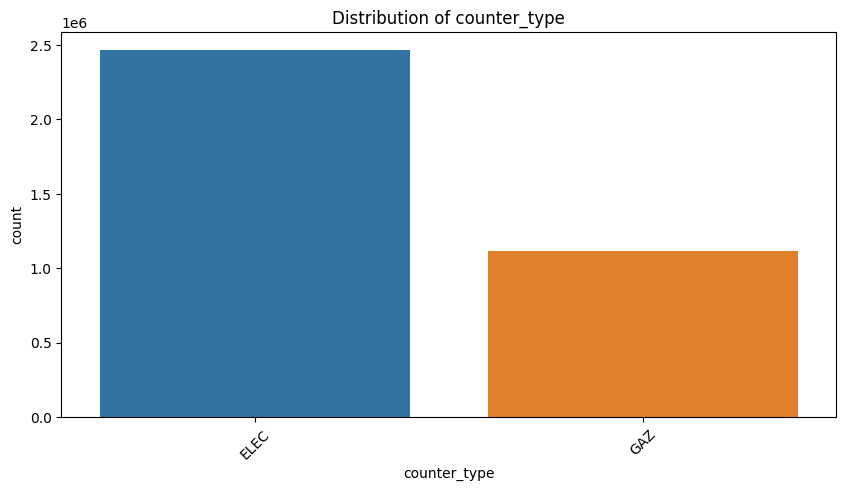

In [45]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=X_train, order=X_train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

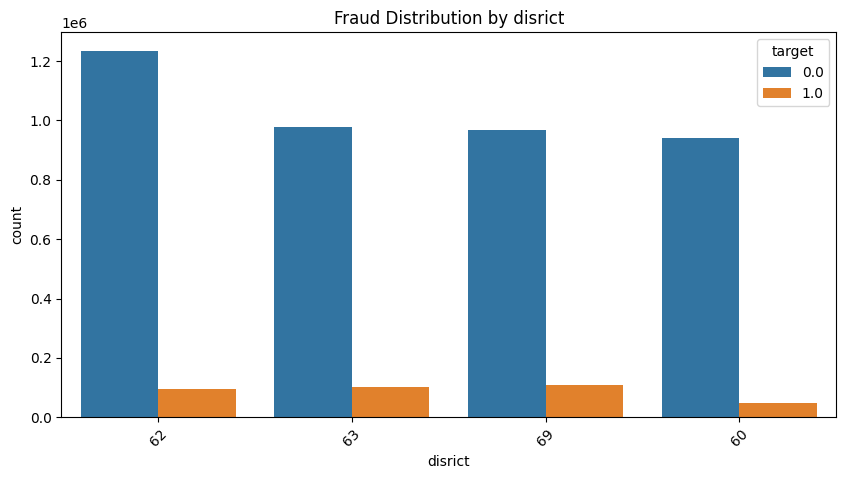

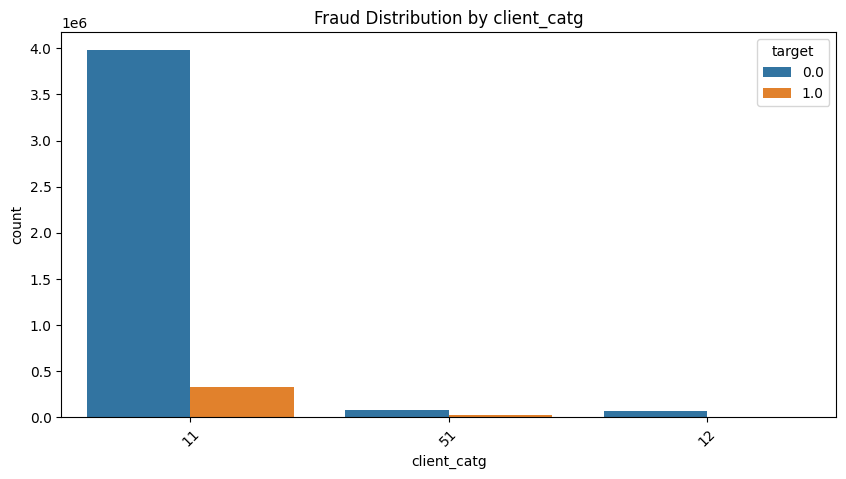

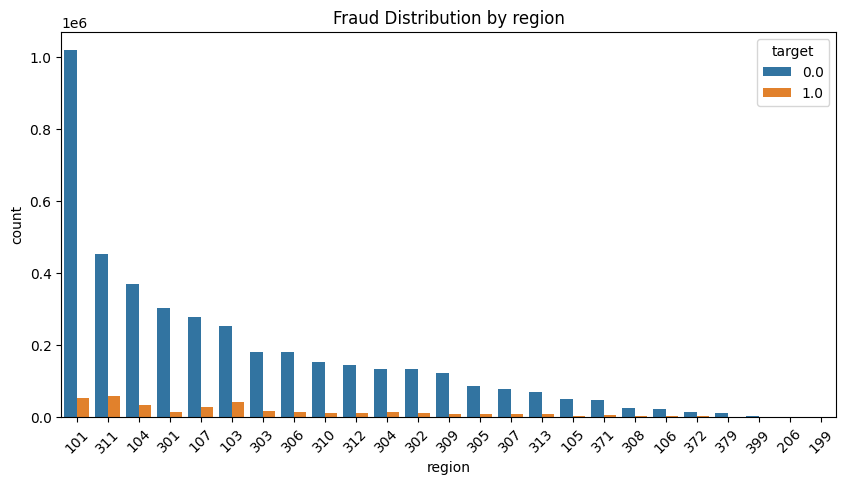

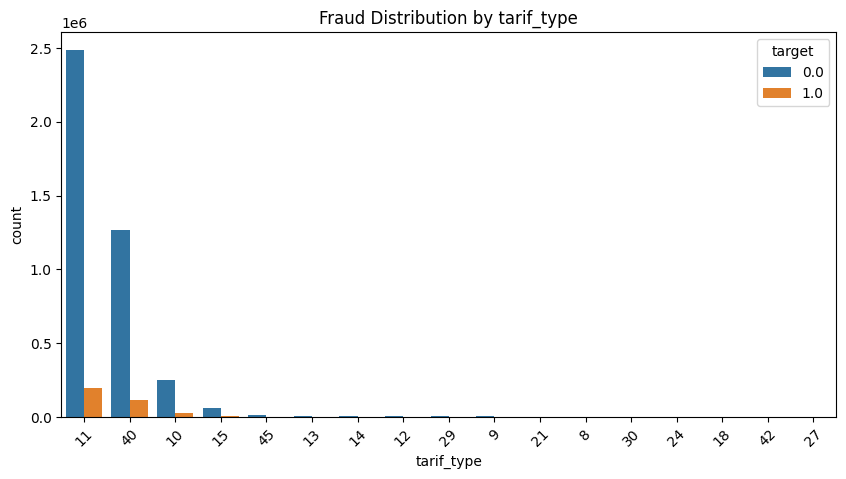

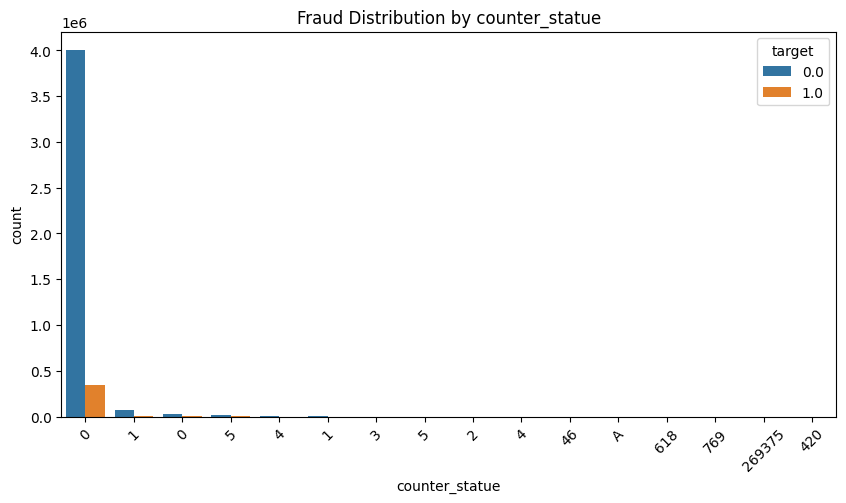

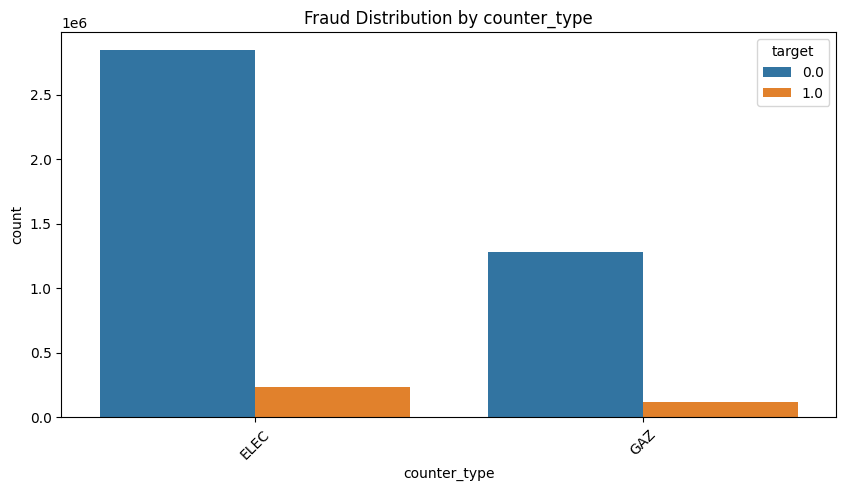

In [46]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='target', data=df_no_duplicates, order=df_no_duplicates[col].value_counts().index)
    plt.title(f"Fraud Distribution by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [47]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(df_no_duplicates[col], df_no_duplicates['target'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {col}:")
    print(f"Chi2 Statistic: {chi2}, P-value: {p}\n")

Chi-Square Test for disrict:
Chi2 Statistic: 23348.05083267355, P-value: 0.0

Chi-Square Test for client_catg:
Chi2 Statistic: 25377.620576243706, P-value: 0.0

Chi-Square Test for region:
Chi2 Statistic: 49529.96570411292, P-value: 0.0

Chi-Square Test for tarif_type:
Chi2 Statistic: 7282.998178593814, P-value: 0.0

Chi-Square Test for counter_statue:
Chi2 Statistic: 299.23352603539047, P-value: 8.065999327544528e-55

Chi-Square Test for counter_type:
Chi2 Statistic: 613.6580099133262, P-value: 1.791134764817036e-135



In [48]:
for col in categorical_cols:
    print(f"Value counts for {col}:\n{X_train[col].value_counts()}\n")

Value counts for disrict:
disrict
62    1065101
63     862193
69     862192
60     791904
Name: count, dtype: int64

Value counts for client_catg:
client_catg
11    3443991
51      83006
12      54393
Name: count, dtype: int64

Value counts for region:
region
101    855279
311    407710
104    320682
301    253095
107    243086
103    235664
303    158022
306    156254
310    132240
312    124950
304    117306
302    114910
309    103161
305     75334
307     68475
313     61511
105     42561
371     42388
308     23102
106     19392
372     13618
379     10573
399      1269
206       807
199         1
Name: count, dtype: int64

Value counts for tarif_type:
tarif_type
11    2142830
40    1104473
10     221362
15      57969
45      14010
13       9285
14       9258
12       9089
29       8090
9        4868
21         80
8          35
30         30
24          6
18          4
42          1
Name: count, dtype: int64

Value counts for counter_statue:
counter_statue
0      3477587
1        

In [49]:
for col in categorical_cols:
    missing_count = X_train[col].isnull().sum()
    print(f"Missing values in {col}: {missing_count}")

Missing values in disrict: 0
Missing values in client_catg: 0
Missing values in region: 0
Missing values in tarif_type: 0
Missing values in counter_statue: 0
Missing values in counter_type: 0


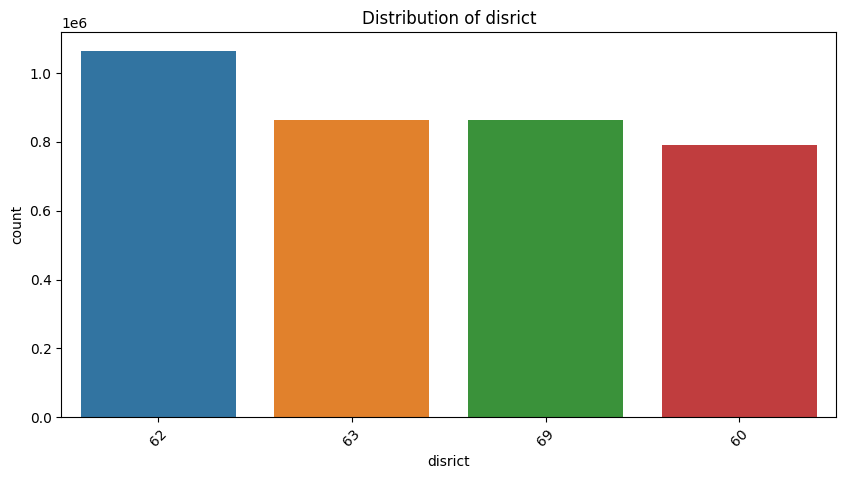

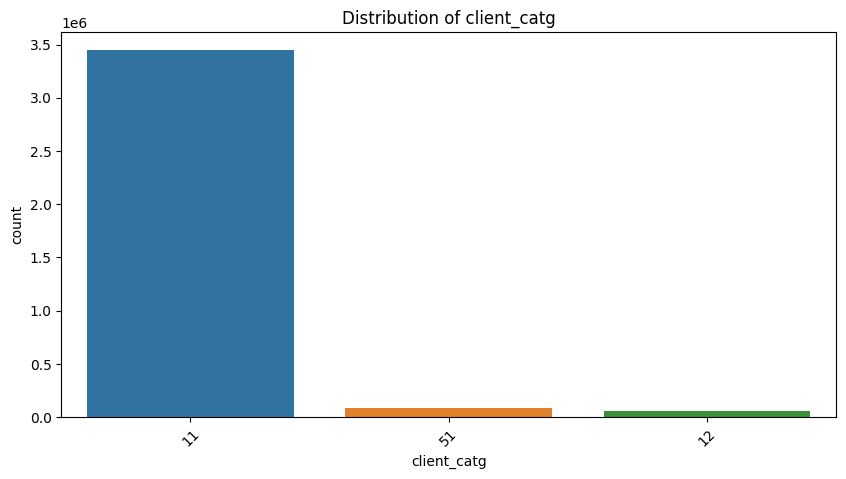

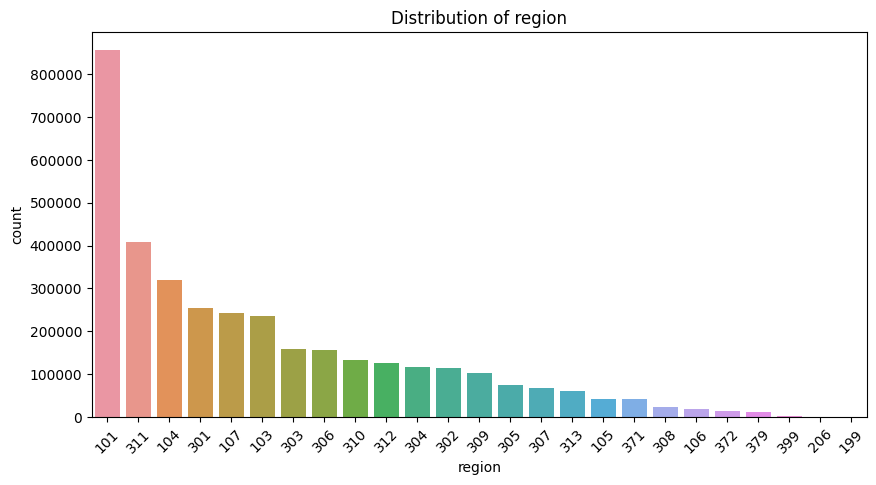

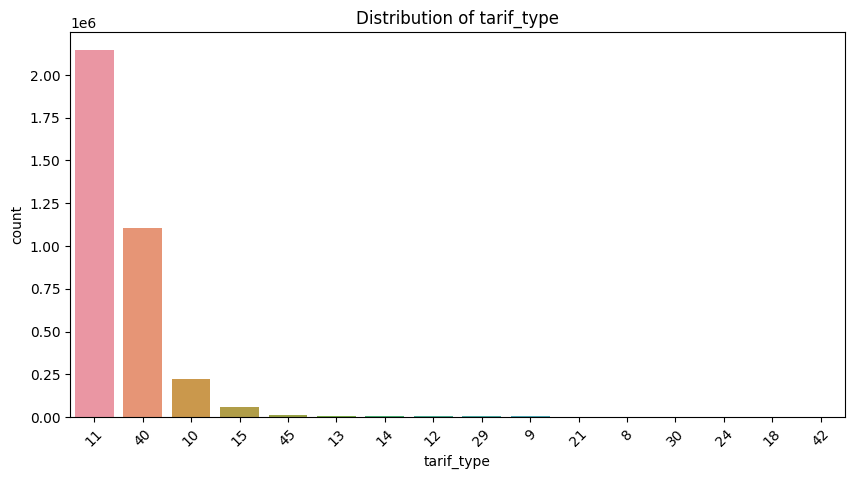

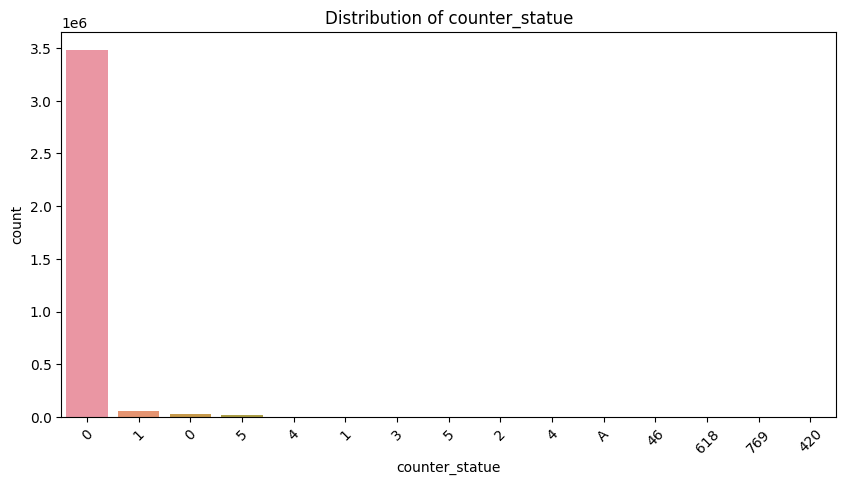

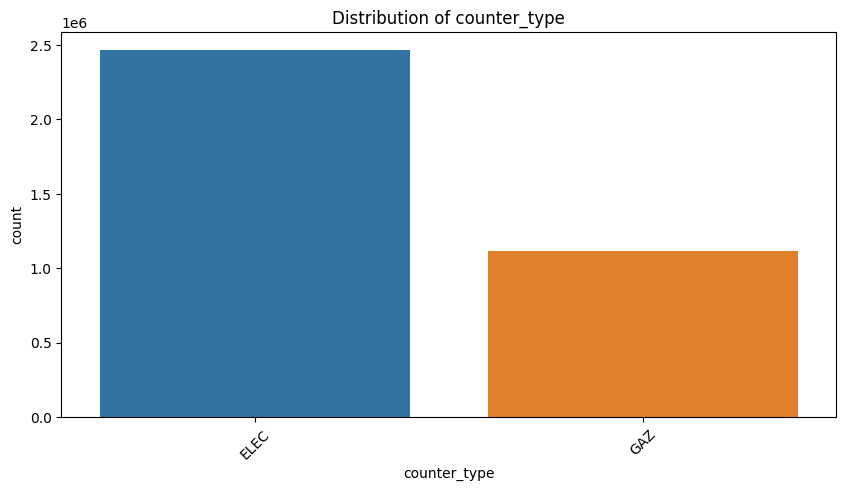

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=X_train, order=X_train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

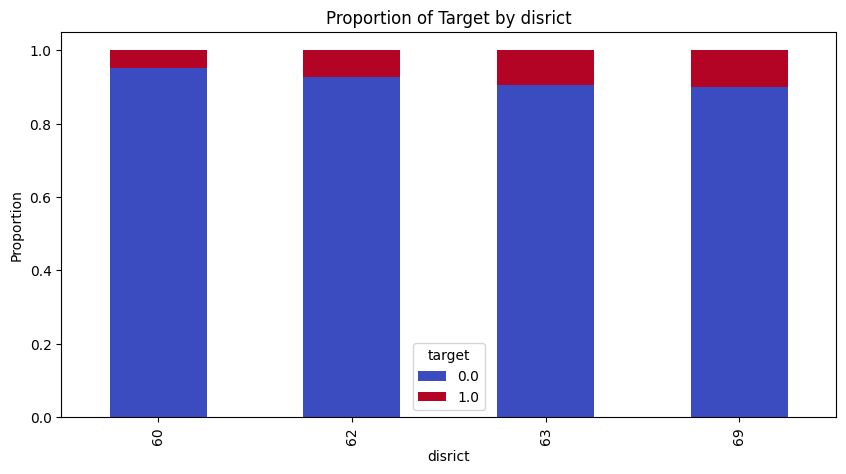

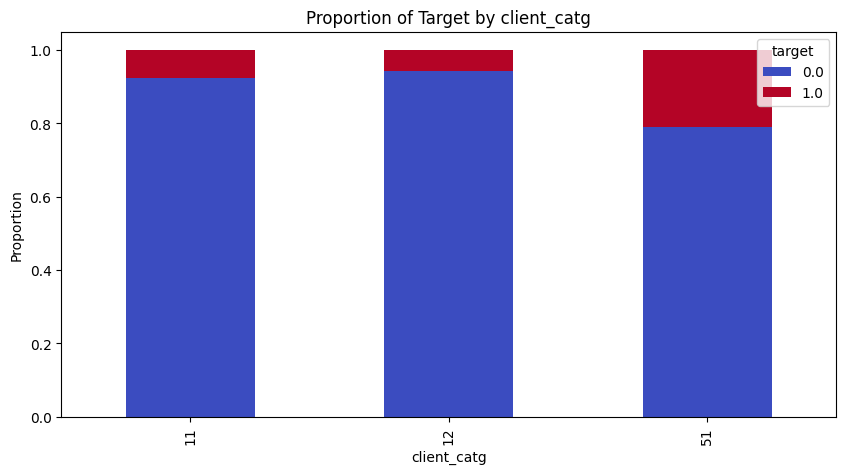

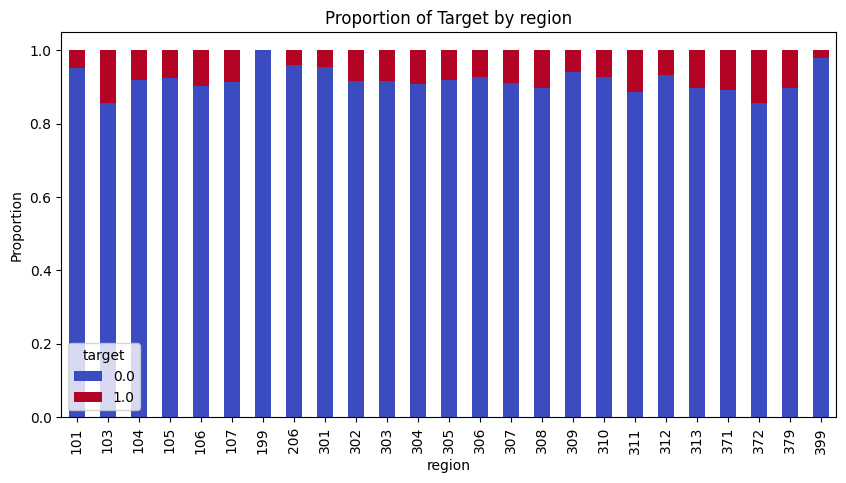

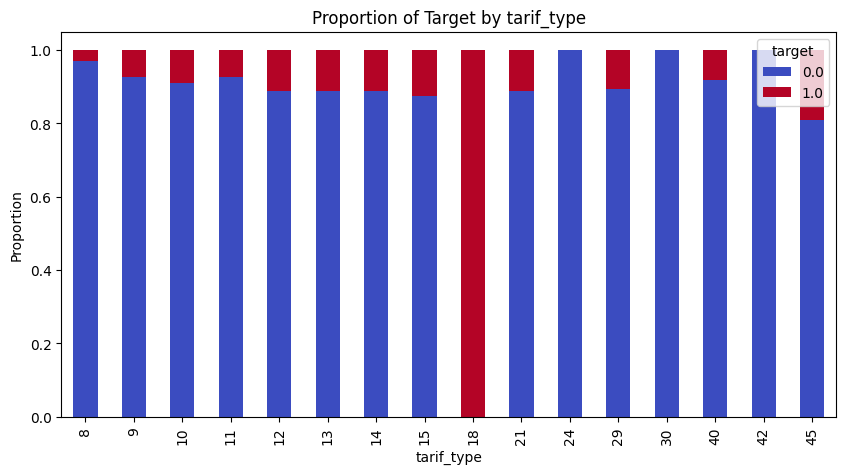

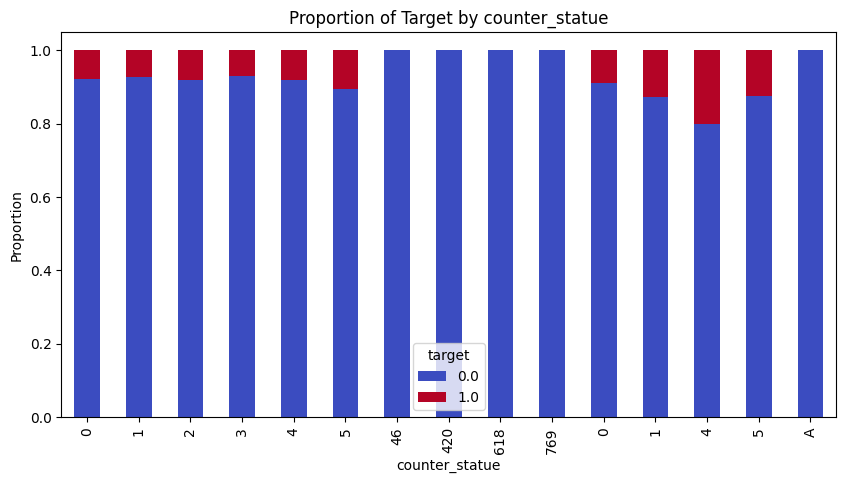

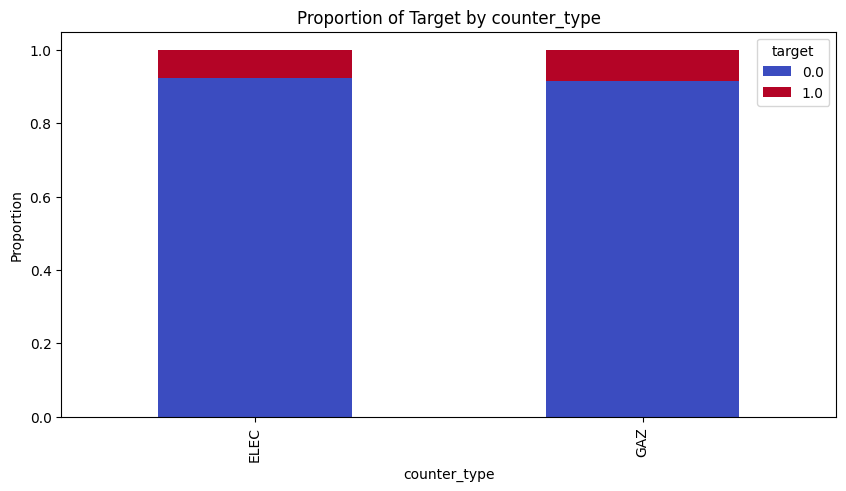

In [51]:
X_train['target'] = y_train  # Combine for analysis

for col in categorical_cols:
    cross_tab = pd.crosstab(X_train[col], X_train['target'], normalize='index')
    cross_tab.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='coolwarm')
    plt.title(f"Proportion of Target by {col}")
    plt.ylabel('Proportion')
    plt.show()

# Drop the target column afterward if modifying X_train directly
X_train.drop('target', axis=1, inplace=True)

In [52]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(X_train[col], y_train)
    chi2_stat, p_value, dof, _ = chi2_contingency(contingency_table)
    print(f"Chi-Square Test for {col}:\nChi2 Statistic: {chi2_stat}, P-value: {p_value}\n")

Chi-Square Test for disrict:
Chi2 Statistic: 18714.861282867387, P-value: 0.0

Chi-Square Test for client_catg:
Chi2 Statistic: 20108.22160239135, P-value: 0.0

Chi-Square Test for region:
Chi2 Statistic: 39733.79654274025, P-value: 0.0

Chi-Square Test for tarif_type:
Chi2 Statistic: 5780.462351319008, P-value: 0.0

Chi-Square Test for counter_statue:
Chi2 Statistic: 244.73241299375871, P-value: 3.5262560245617586e-44

Chi-Square Test for counter_type:
Chi2 Statistic: 465.27008035367487, P-value: 3.4280313986184377e-103



In [53]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 != col2:
            score = cramers_v(X_train[col1], X_train[col2])
            print(f"Cramér's V between {col1} and {col2}: {score}")

Cramér's V between disrict and client_catg: 0.03914857463179366
Cramér's V between disrict and region: 0.9759517662012726
Cramér's V between disrict and tarif_type: 0.10813151996768477
Cramér's V between disrict and counter_statue: 0.01768520342305481
Cramér's V between disrict and counter_type: 0.08222712843721189
Cramér's V between client_catg and disrict: 0.03914857463179366
Cramér's V between client_catg and region: 0.05975170170432731
Cramér's V between client_catg and tarif_type: 0.23120655969534207
Cramér's V between client_catg and counter_statue: 0.006742864296838321
Cramér's V between client_catg and counter_type: 0.010740910835216312
Cramér's V between region and disrict: 0.9759517662012727
Cramér's V between region and client_catg: 0.05975170170432731
Cramér's V between region and tarif_type: 0.10982883343232286
Cramér's V between region and counter_statue: 0.015261869643301076
Cramér's V between region and counter_type: 0.14607022456511165
Cramér's V between tarif_type and

In [54]:
for col in categorical_cols:
    unique_count = X_train[col].nunique()
    print(f"{col}: {unique_count} unique values")

disrict: 4 unique values
client_catg: 3 unique values
region: 25 unique values
tarif_type: 16 unique values
counter_statue: 15 unique values
counter_type: 2 unique values


In [55]:
threshold = 0.01 * len(X_train)
for col in categorical_cols:
    rare_categories = X_train[col].value_counts()[X_train[col].value_counts() < threshold]
    print(f"Rare categories in {col}:\n{rare_categories}")

Rare categories in disrict:
Series([], Name: count, dtype: int64)
Rare categories in client_catg:
Series([], Name: count, dtype: int64)
Rare categories in region:
region
308    23102
106    19392
372    13618
379    10573
399     1269
206      807
199        1
Name: count, dtype: int64
Rare categories in tarif_type:
tarif_type
45    14010
13     9285
14     9258
12     9089
29     8090
9      4868
21       80
8        35
30       30
24        6
18        4
42        1
Name: count, dtype: int64
Rare categories in counter_statue:
counter_statue
0      25544
5      16365
4       2160
1        429
3        199
5        121
2         25
4         20
A         12
46         9
618        7
769        4
420        1
Name: count, dtype: int64
Rare categories in counter_type:
Series([], Name: count, dtype: int64)


In [56]:
for col in categorical_cols:
    print(f"Unique values in {col}:\n{X_train[col].unique()}\n")

Unique values in disrict:
[60 62 69 63]

Unique values in client_catg:
[11 51 12]

Unique values in region:
[101 301 310 103 107 312 104 305 105 304 303 309 206 302 306 311 372 371
 313 307 106 308 379 399 199]

Unique values in tarif_type:
[10 40 11 29  9 14 45 15 13 12 21  8 30 24 18 42]

Unique values in counter_statue:
[0 '0' 5 1 4 '1' '5' 3 'A' 46 '4' 2 769 420 618]

Unique values in counter_type:
['ELEC' 'GAZ']



### Exploring the Categorical Data

In [57]:
categorical_cols = ['disrict', 'client_catg', 'region', 'tarif_type', 'counter_statue', 'counter_type']

[60 62 69 63]
disrict
62    1065101
63     862193
69     862192
60     791904
Name: count, dtype: int64


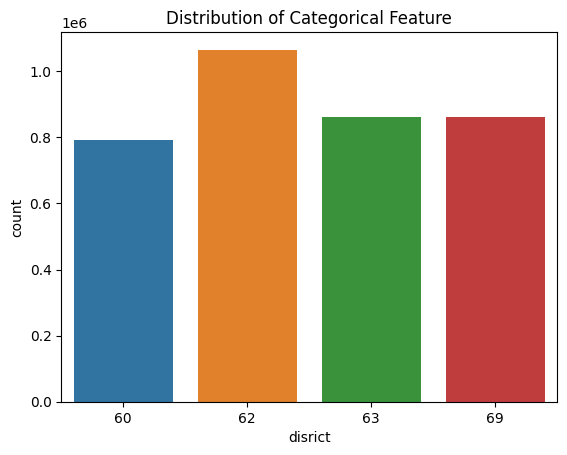

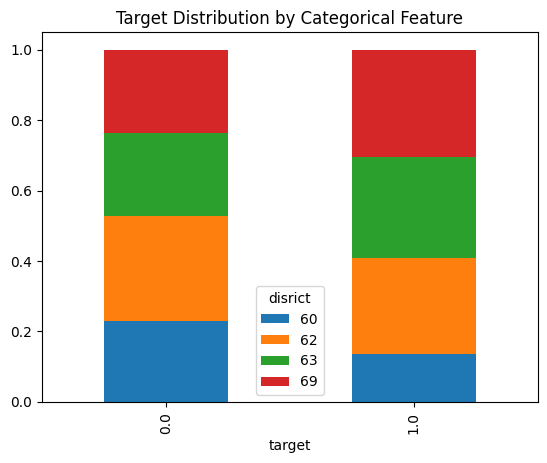

In [58]:
# Unique values and value counts
print(X_train['disrict'].unique())
print(X_train['disrict'].value_counts())

# Visualization
sns.countplot(x='disrict', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['disrict'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

[11 51 12]
client_catg
11    3443991
51      83006
12      54393
Name: count, dtype: int64


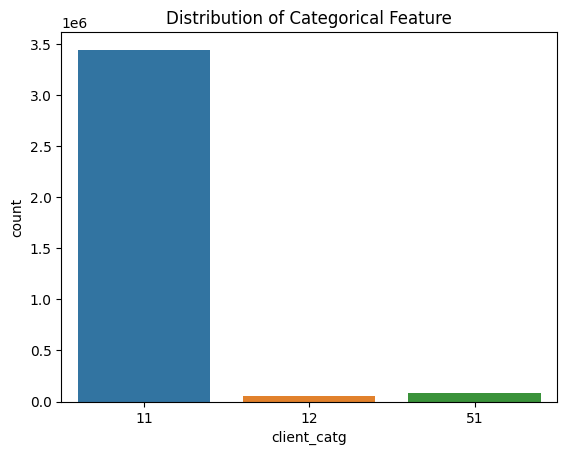

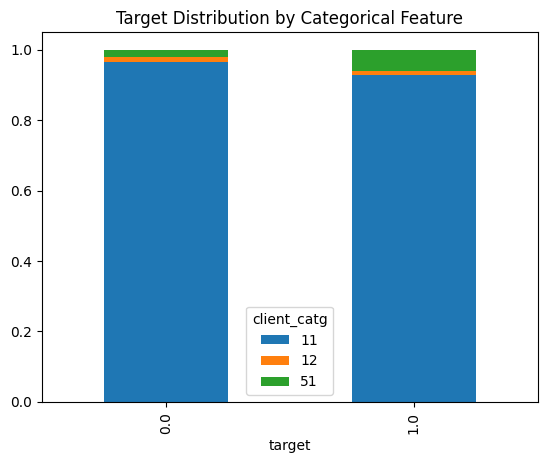

In [59]:
# Unique values and value counts
print(X_train['client_catg'].unique())
print(X_train['client_catg'].value_counts())

# Visualization
sns.countplot(x='client_catg', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['client_catg'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

[101 301 310 103 107 312 104 305 105 304 303 309 206 302 306 311 372 371
 313 307 106 308 379 399 199]
region
101    855279
311    407710
104    320682
301    253095
107    243086
103    235664
303    158022
306    156254
310    132240
312    124950
304    117306
302    114910
309    103161
305     75334
307     68475
313     61511
105     42561
371     42388
308     23102
106     19392
372     13618
379     10573
399      1269
206       807
199         1
Name: count, dtype: int64


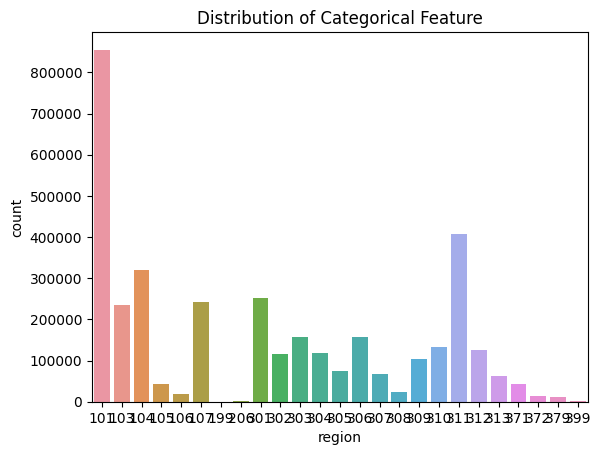

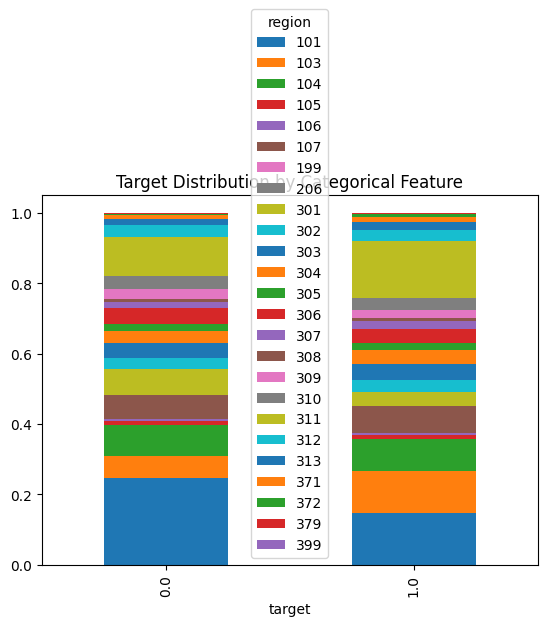

In [60]:
# Unique values and value counts
print(X_train['region'].unique())
print(X_train['region'].value_counts())

# Visualization
sns.countplot(x='region', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['region'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

[10 40 11 29  9 14 45 15 13 12 21  8 30 24 18 42]
tarif_type
11    2142830
40    1104473
10     221362
15      57969
45      14010
13       9285
14       9258
12       9089
29       8090
9        4868
21         80
8          35
30         30
24          6
18          4
42          1
Name: count, dtype: int64


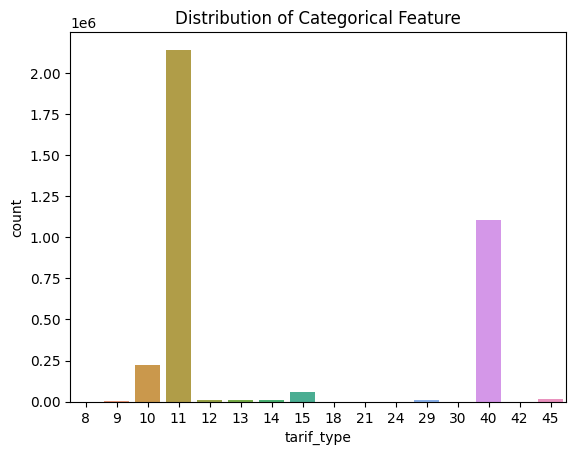

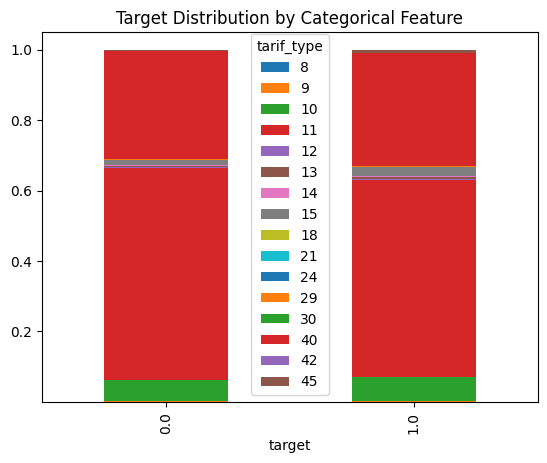

In [61]:
# Unique values and value counts
print(X_train['tarif_type'].unique())
print(X_train['tarif_type'].value_counts())

# Visualization
sns.countplot(x='tarif_type', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['tarif_type'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

[0 '0' 5 1 4 '1' '5' 3 'A' 46 '4' 2 769 420 618]
counter_statue
0      3477587
1        58907
0        25544
5        16365
4         2160
1          429
3          199
5          121
2           25
4           20
A           12
46           9
618          7
769          4
420          1
Name: count, dtype: int64


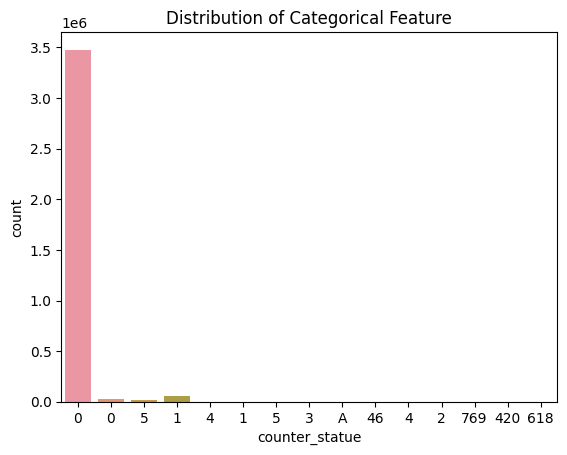

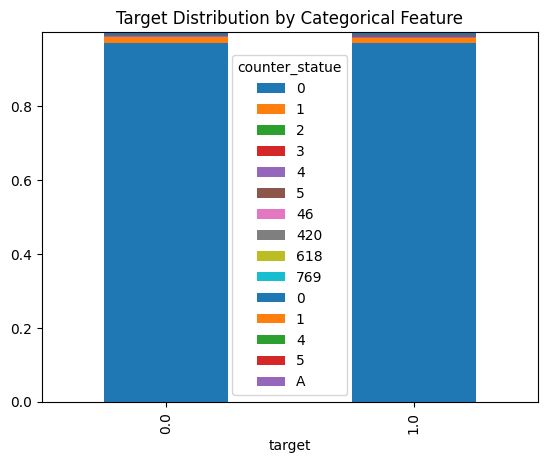

In [62]:

# Unique values and value counts
print(X_train['counter_statue'].unique())
print(X_train['counter_statue'].value_counts())

# Visualization
sns.countplot(x='counter_statue', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['counter_statue'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

['ELEC' 'GAZ']
counter_type
ELEC    2462876
GAZ     1118514
Name: count, dtype: int64


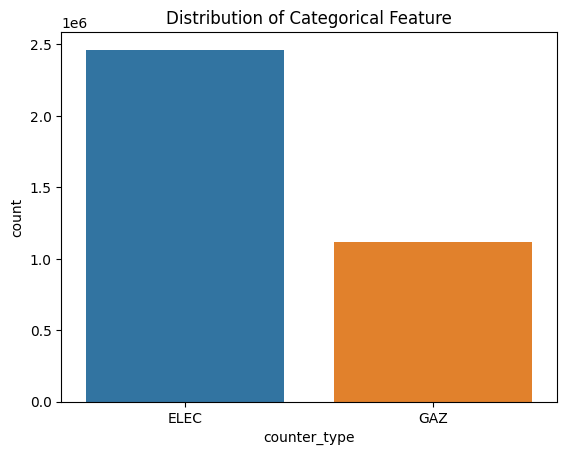

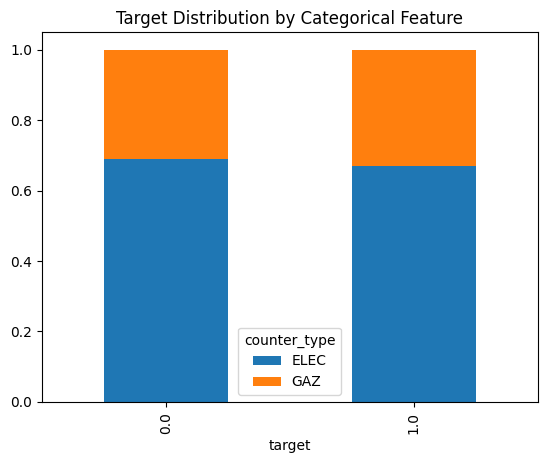

In [63]:

# Unique values and value counts
print(X_train['counter_type'].unique())
print(X_train['counter_type'].value_counts())

# Visualization
sns.countplot(x='counter_type', data=X_train)
plt.title("Distribution of Categorical Feature")
plt.show()

# Relationship with target
pd.crosstab(y_train, X_train['counter_type'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Target Distribution by Categorical Feature")
plt.show()

### Exploring the numerical Featues

In [64]:
numerical_columns = ['counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number']

count    3.581390e+06
mean     1.003024e+00
std      3.082906e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.000000e+01
Name: counter_coefficient, dtype: float64


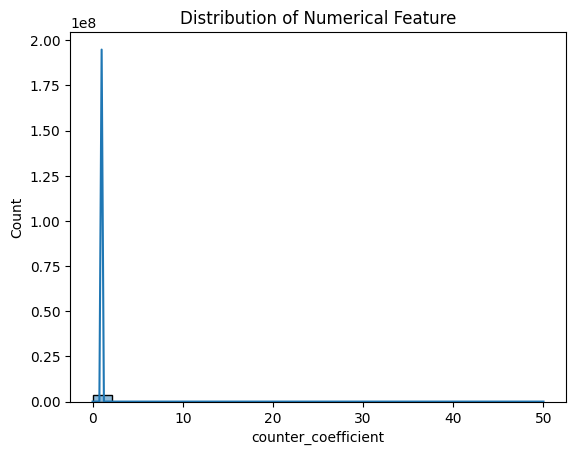

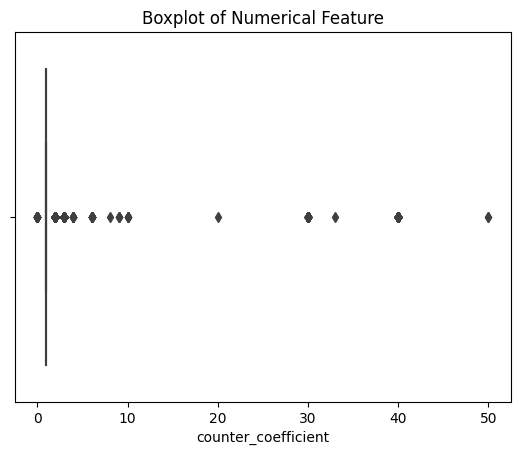

In [65]:
# Summary statistics
print(X_train['counter_coefficient'].describe())

# Visualizations
sns.histplot(X_train['counter_coefficient'], kde=True)
plt.title("Distribution of Numerical Feature")
plt.show()

sns.boxplot(x=X_train['counter_coefficient'])
plt.title("Boxplot of Numerical Feature")
plt.show()

count    3.581390e+06
mean     4.109425e+02
std      7.961973e+02
min      0.000000e+00
25%      7.900000e+01
50%      2.740000e+02
75%      6.000000e+02
max      9.999100e+05
Name: consommation_level_1, dtype: float64


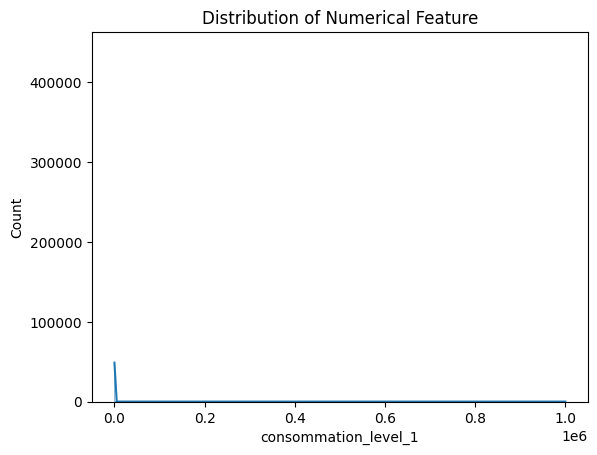

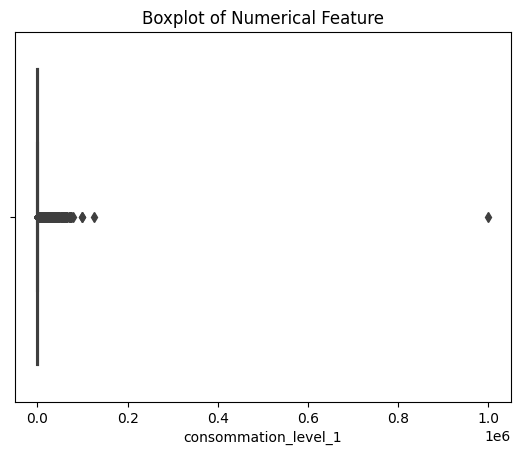

In [66]:
# Summary statistics
print(X_train['consommation_level_1'].describe())

# Visualizations
sns.histplot(X_train['consommation_level_1'], kde=True)
plt.title("Distribution of Numerical Feature")
plt.show()

sns.boxplot(x=X_train['consommation_level_1'])
plt.title("Boxplot of Numerical Feature")
plt.show()

count    3.581390e+06
mean     1.095864e+02
std      1.299030e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.990730e+05
Name: consommation_level_2, dtype: float64


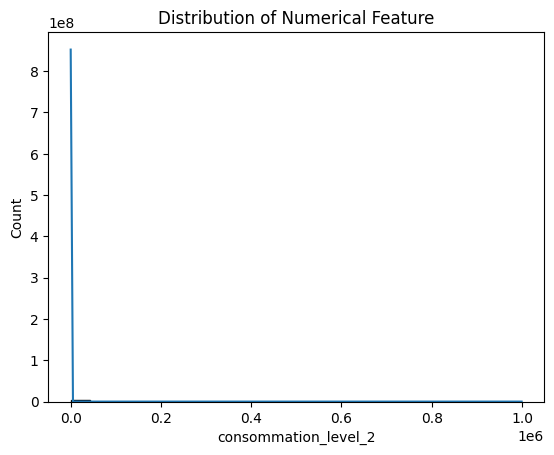

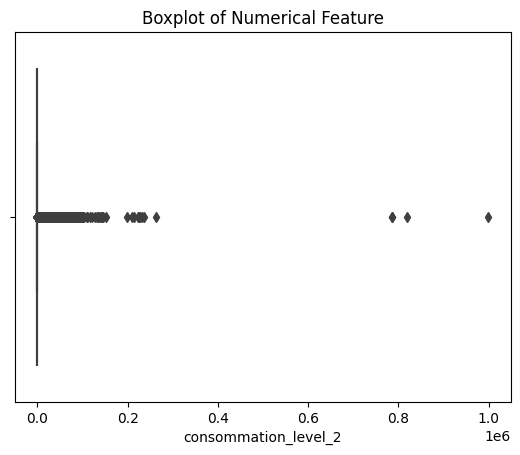

In [67]:
# Summary statistics
print(X_train['consommation_level_2'].describe())

# Visualizations
sns.histplot(X_train['consommation_level_2'], kde=True)
plt.title("Distribution of Numerical Feature")
plt.show()

sns.boxplot(x=X_train['consommation_level_2'])
plt.title("Boxplot of Numerical Feature")
plt.show()

count    3.581390e+06
mean     2.024594e+01
std      1.530641e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.449200e+04
Name: consommation_level_3, dtype: float64


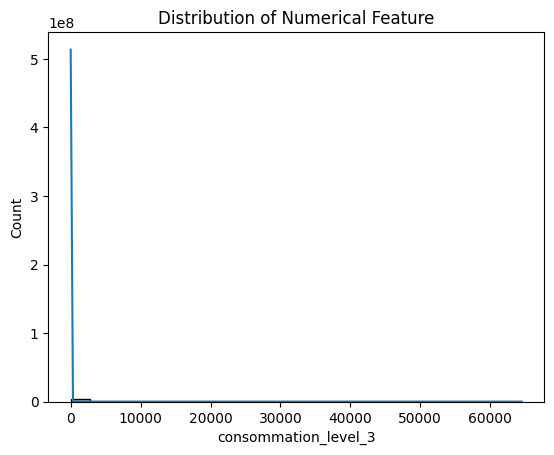

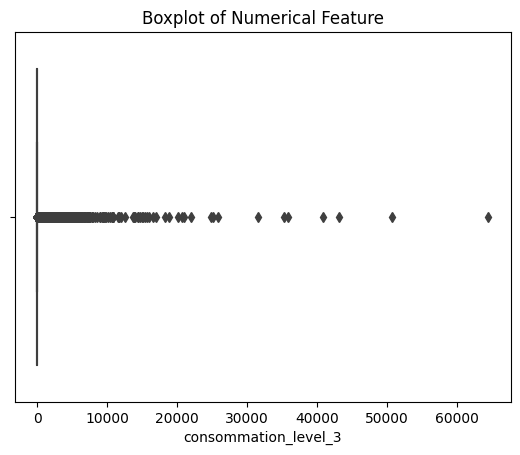

In [68]:
# Summary statistics
print(X_train['consommation_level_3'].describe())

# Visualizations
sns.histplot(X_train['consommation_level_3'], kde=True)
plt.title("Distribution of Numerical Feature")
plt.show()

sns.boxplot(x=X_train['consommation_level_3'])
plt.title("Boxplot of Numerical Feature")
plt.show()

count    3.581390e+06
mean     5.305447e+01
std      8.925410e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.479460e+05
Name: consommation_level_4, dtype: float64


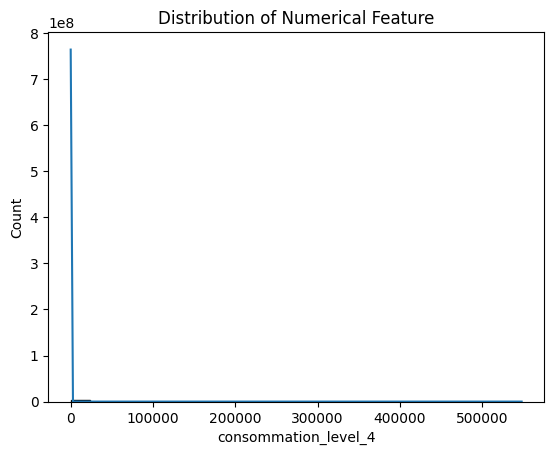

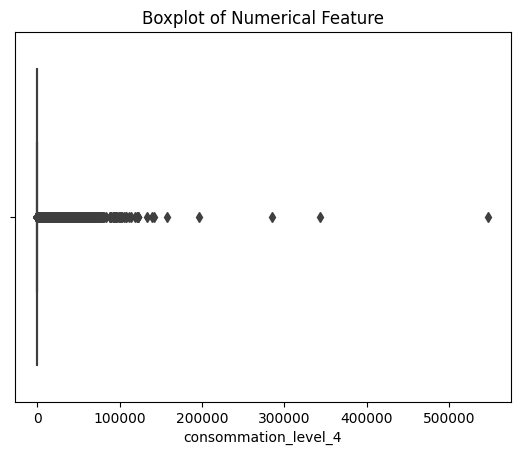

In [69]:
# Summary statistics
print(X_train['consommation_level_4'].describe())

# Visualizations
sns.histplot(X_train['consommation_level_4'], kde=True)
plt.title("Distribution of Numerical Feature")
plt.show()

sns.boxplot(x=X_train['consommation_level_4'])
plt.title("Boxplot of Numerical Feature")
plt.show()

In [70]:
from scipy.stats import skew

In [71]:
numerical_columns = ['counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4']

In [72]:
skewness = X_train[numerical_columns].apply(skew)
print(skewness.sort_values(ascending=False))

consommation_level_1    563.569608
consommation_level_2    348.429986
consommation_level_4    130.711977
counter_coefficient     117.005825
consommation_level_3     71.913468
dtype: float64


### Handling Outliers


In [73]:
Q1 = X_train['counter_coefficient'].quantile(0.25)
Q3 = X_train['counter_coefficient'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = X_train[(X_train['counter_coefficient'] < lower_bound) | (X_train['counter_coefficient'] > upper_bound)]

In [74]:
outliers

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
1398573,60,train_Client_16033,11,101,10/12/1993,2009-02-10,11,17828,0,565,6,2,5,300,1062,0,0,83945,84490,ELEC
1260553,62,train_Client_134275,11,304,26/02/2003,2007-01-11,11,120222,0,506,6,2,1200,3384,0,0,103038,105330,4,ELEC
1531017,60,train_Client_1965,51,101,20/02/2001,2013-04-03,11,99133469,0,532,9,2,300,13612,0,0,45927,52883,1,ELEC
3005210,60,train_Client_59968,51,101,24/05/2002,2008-02-22,11,120214,0,532,6,3,1200,145509,0,0,955614,4517,4,ELEC
3292550,60,train_Client_67880,51,101,31/12/1994,2012-02-03,11,983400,0,483,9,2,600,13990,0,0,22179,29474,2,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260489,62,train_Client_134275,11,304,26/02/2003,2017-03-01,11,120222,0,506,9,2,200,100,8,0,152518,152672,1,ELEC
3292633,60,train_Client_67880,51,101,31/12/1994,2017-02-11,11,983400,0,483,9,2,200,100,200,312,74723,75129,1,ELEC
1398519,60,train_Client_16033,11,101,10/12/1993,2017-01-24,11,17828,0,565,8,2,5,800,400,800,3915,34511,36877,ELEC
2722154,60,train_Client_52325,51,101,31/12/1996,2015-02-10,11,8018,0,532,9,2,400,200,400,6416,360321,364029,2,ELEC


In [75]:
Q1 = X_train['consommation_level_1'].quantile(0.25)
Q3 = X_train['consommation_level_1'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = X_train[(X_train['consommation_level_1'] < lower_bound) | (X_train['consommation_level_1'] > upper_bound)]

In [76]:
outliers

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
3650260,62,train_Client_77597,11,305,12/06/1984,2009-09-01,11,389796,0,207,6,1,1572,0,0,0,37341,38913,8,ELEC
928151,69,train_Client_125212,11,104,03/12/2009,2010-12-14,40,23063563,0,5,6,1,3807,0,0,0,9509,13316,4,GAZ
3501936,69,train_Client_73607,11,107,02/07/2010,2014-07-02,9,2268890,0,202,9,1,1763,0,0,0,3939,5702,8,ELEC
2860098,60,train_Client_56069,51,101,20/12/1988,2016-05-01,45,7032701,0,25,9,1,3855,0,0,0,637392,641247,1,GAZ
1239803,62,train_Client_133705,11,310,15/04/1983,2015-12-28,13,451615,0,413,9,1,1403,0,0,0,65578,66981,8,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25340,69,train_Client_100701,11,107,01/12/1994,2014-01-24,11,1331461,0,203,8,1,1600,759,0,0,39737,42096,8,ELEC
2542757,69,train_Client_47403,11,107,03/01/2011,2016-10-17,11,107040,0,413,8,1,1600,799,0,0,15020,17419,8,ELEC
1942979,62,train_Client_31034,11,301,15/04/2010,2017-07-11,11,540559,0,203,8,1,1780,0,0,0,37561,39341,10,ELEC
3356553,69,train_Client_69649,11,104,28/10/1985,2006-11-21,11,2829,0,407,6,1,2400,32,0,0,37370,39802,8,ELEC


In [77]:
# Create the difference feature
X_train['difference_index'] = X_train['new_index'] - X_train['old_index']



In [78]:
X_train

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,counter_number,counter_statue,counter_code,...,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,difference_index
3661429,60,train_Client_77893,11,101,01/08/1983,2019-01-29,10,11116938,0,202,...,1,0,0,0,0,45,45,8,ELEC,0
4183240,62,train_Client_92012,11,301,30/11/2000,2014-12-16,40,98321,0,5,...,1,54,0,0,0,4353,4407,4,GAZ,54
932772,62,train_Client_125341,11,310,21/06/1996,2013-04-19,40,2122011,0,5,...,1,962,0,0,0,9873,10835,4,GAZ,962
4255522,69,train_Client_93961,11,103,09/06/2014,2018-04-25,40,481695,0,5,...,1,157,0,0,0,1046,1203,4,GAZ,157
914999,60,train_Client_124856,11,101,01/11/1999,2006-02-14,11,184353,0,207,...,1,1200,4671,0,0,63579,69450,4,ELEC,5871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,62,train_Client_17055,11,304,12/06/2018,2018-10-19,11,2185700298000,0,207,...,1,1,0,0,0,0,1,6,ELEC,1
3459845,63,train_Client_72436,11,101,05/09/1995,2013-05-09,40,4238833,0,5,...,1,44,0,0,0,1307,1351,4,GAZ,44
799362,63,train_Client_121648,11,312,21/12/2012,2016-09-11,11,418372,0,207,...,1,35,0,0,0,409,444,4,ELEC,35
4136963,69,train_Client_90757,11,107,29/04/2011,2018-01-02,40,4238171,0,5,...,1,129,0,0,0,1769,1898,4,GAZ,129


In [79]:
X_test['difference_index'] = X_test['new_index'] - X_test['old_index']

In [80]:
X_test

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,counter_number,counter_statue,counter_code,...,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,difference_index
4453890,60,train_Client_99380,51,101,13/11/2007,2009-02-04,11,500921,0,420,...,1,300,1857,0,0,41818,43975,1,ELEC,2157
747931,62,train_Client_120204,11,309,18/04/1985,2007-03-04,11,478083,0,203,...,1,671,0,0,0,19230,19901,4,ELEC,671
1640197,69,train_Client_22681,11,104,28/09/2006,2008-05-05,40,6834257,0,5,...,1,681,0,0,0,813,1494,4,GAZ,681
2977036,63,train_Client_59209,11,313,29/02/2000,2012-07-11,40,0,0,5,...,1,0,0,0,0,0,0,4,GAZ,0
3718962,69,train_Client_79467,11,104,30/05/1978,2011-08-15,11,791715,0,203,...,1,1200,102,0,0,79535,80837,4,ELEC,1302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,63,train_Client_101207,11,306,31/07/2007,2015-04-22,40,4175825,0,5,...,1,193,0,0,0,663,856,4,GAZ,193
787699,69,train_Client_121325,11,104,13/11/1986,2006-07-09,11,616917,0,203,...,1,339,0,0,0,13634,13973,4,ELEC,339
2335528,62,train_Client_41700,11,305,26/05/2014,2016-01-13,11,248021,0,207,...,1,497,0,0,0,3243,3740,4,ELEC,497
4208295,62,train_Client_92700,11,302,29/08/2005,2011-07-14,11,132351,0,413,...,1,854,0,0,0,12284,13138,4,ELEC,854


In [81]:
X_train['reading_remarque'].unique()

array([  6,   9,   8,   7, 203, 207,   5, 413])

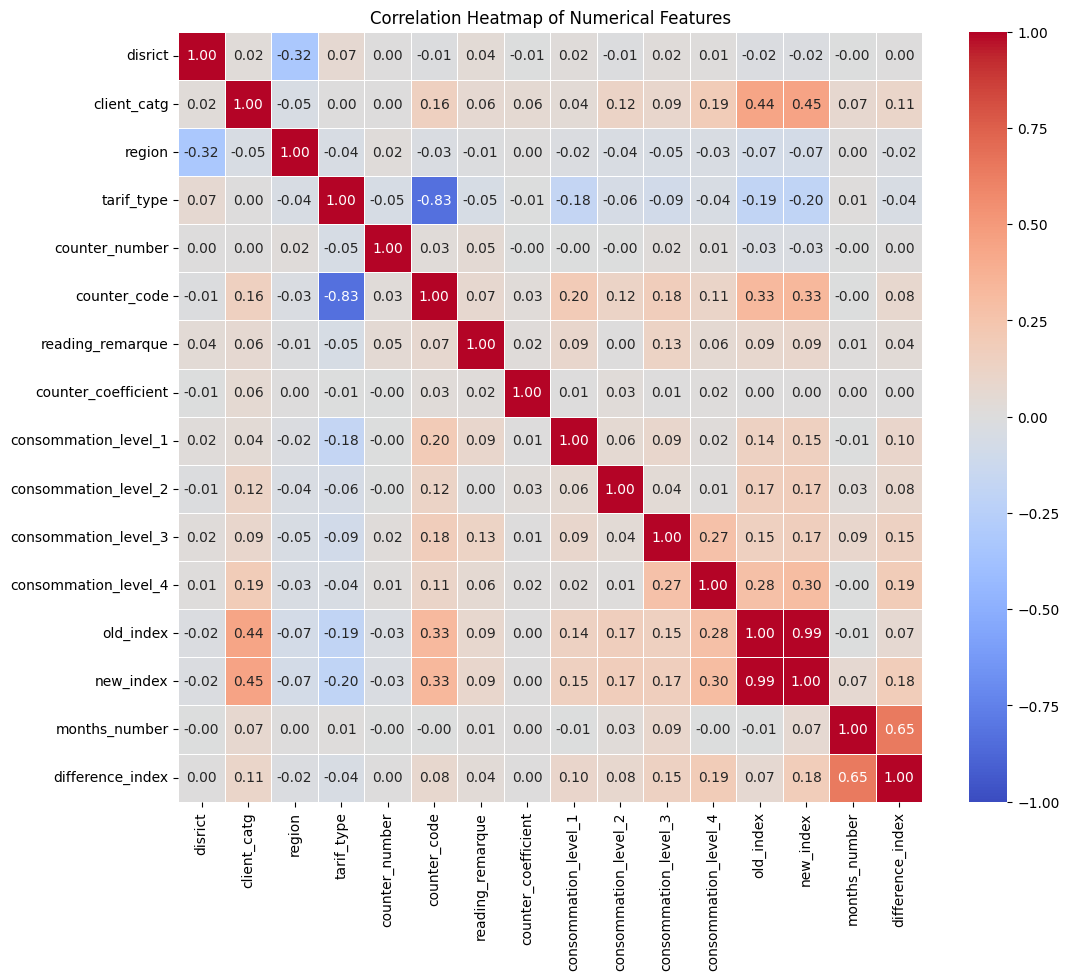

In [82]:
# Select only numerical columns
numerical_columns_ = X_train.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix only for numerical columns
correlation_matrix = X_train[numerical_columns_].corr()

# Create a heatmap using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

# Display the heatmap
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [83]:
X_train['tarif_type']

3661429    10
4183240    40
932772     40
4255522    40
914999     11
           ..
1436383    11
3459845    40
799362     11
4136963    40
1143694    11
Name: tarif_type, Length: 3581390, dtype: int64

In [84]:
X_train['tarif_type'].unique()

array([10, 40, 11, 29,  9, 14, 45, 15, 13, 12, 21,  8, 30, 24, 18, 42])

In [85]:
print(X_train['tarif_type'].value_counts())

tarif_type
11    2142830
40    1104473
10     221362
15      57969
45      14010
13       9285
14       9258
12       9089
29       8090
9        4868
21         80
8          35
30         30
24          6
18          4
42          1
Name: count, dtype: int64


In [86]:
print(X_train['client_id'].value_counts())

client_id
train_Client_116878    346
train_Client_9263      310
train_Client_130245    260
train_Client_56894     258
train_Client_61728     252
                      ... 
train_Client_117194      1
train_Client_56039       1
train_Client_100002      1
train_Client_52341       1
train_Client_117003      1
Name: count, Length: 134433, dtype: int64


In [87]:
X_train.groupby(by='region').tarif_type.mean()

region
101    19.635504
103    22.670578
104    21.461392
105    21.584925
106    22.213645
107    20.866796
199    40.000000
206    24.116481
301    19.465205
302    18.654051
303    19.865012
304    20.940191
305    19.179229
306    19.636649
307    12.735144
308    17.156090
309    20.169851
310    19.864209
311    22.304030
312    19.311645
313    18.769472
371    11.325021
372    12.999266
379    14.565497
399    13.845548
Name: tarif_type, dtype: float64

In [88]:
X_train['counter_statue'].unique()

array([0, '0', 5, 1, 4, '1', '5', 3, 'A', 46, '4', 2, 769, 420, 618],
      dtype=object)

In [89]:
print(X_train['counter_statue'].value_counts())

counter_statue
0      3477587
1        58907
0        25544
5        16365
4         2160
1          429
3          199
5          121
2           25
4           20
A           12
46           9
618          7
769          4
420          1
Name: count, dtype: int64


In [90]:
drop_list = ['counter_number', 'counter_code', 'counter_statue', 'old_index', 'new_index', 'months_number']
X_train_dropped = X_train.drop(columns=drop_list, inplace=True)

In [91]:
X_train

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,difference_index
3661429,60,train_Client_77893,11,101,01/08/1983,2019-01-29,10,6,1,0,0,0,0,ELEC,0
4183240,62,train_Client_92012,11,301,30/11/2000,2014-12-16,40,9,1,54,0,0,0,GAZ,54
932772,62,train_Client_125341,11,310,21/06/1996,2013-04-19,40,9,1,962,0,0,0,GAZ,962
4255522,69,train_Client_93961,11,103,09/06/2014,2018-04-25,40,9,1,157,0,0,0,GAZ,157
914999,60,train_Client_124856,11,101,01/11/1999,2006-02-14,11,6,1,1200,4671,0,0,ELEC,5871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,62,train_Client_17055,11,304,12/06/2018,2018-10-19,11,9,1,1,0,0,0,ELEC,1
3459845,63,train_Client_72436,11,101,05/09/1995,2013-05-09,40,8,1,44,0,0,0,GAZ,44
799362,63,train_Client_121648,11,312,21/12/2012,2016-09-11,11,9,1,35,0,0,0,ELEC,35
4136963,69,train_Client_90757,11,107,29/04/2011,2018-01-02,40,9,1,129,0,0,0,GAZ,129


In [92]:
X_test

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,counter_number,counter_statue,counter_code,...,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,difference_index
4453890,60,train_Client_99380,51,101,13/11/2007,2009-02-04,11,500921,0,420,...,1,300,1857,0,0,41818,43975,1,ELEC,2157
747931,62,train_Client_120204,11,309,18/04/1985,2007-03-04,11,478083,0,203,...,1,671,0,0,0,19230,19901,4,ELEC,671
1640197,69,train_Client_22681,11,104,28/09/2006,2008-05-05,40,6834257,0,5,...,1,681,0,0,0,813,1494,4,GAZ,681
2977036,63,train_Client_59209,11,313,29/02/2000,2012-07-11,40,0,0,5,...,1,0,0,0,0,0,0,4,GAZ,0
3718962,69,train_Client_79467,11,104,30/05/1978,2011-08-15,11,791715,0,203,...,1,1200,102,0,0,79535,80837,4,ELEC,1302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,63,train_Client_101207,11,306,31/07/2007,2015-04-22,40,4175825,0,5,...,1,193,0,0,0,663,856,4,GAZ,193
787699,69,train_Client_121325,11,104,13/11/1986,2006-07-09,11,616917,0,203,...,1,339,0,0,0,13634,13973,4,ELEC,339
2335528,62,train_Client_41700,11,305,26/05/2014,2016-01-13,11,248021,0,207,...,1,497,0,0,0,3243,3740,4,ELEC,497
4208295,62,train_Client_92700,11,302,29/08/2005,2011-07-14,11,132351,0,413,...,1,854,0,0,0,12284,13138,4,ELEC,854


In [93]:
X_test_dropped = X_test.drop(columns=drop_list, inplace=True)

In [94]:
X_test

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,difference_index
4453890,60,train_Client_99380,51,101,13/11/2007,2009-02-04,11,6,1,300,1857,0,0,ELEC,2157
747931,62,train_Client_120204,11,309,18/04/1985,2007-03-04,11,6,1,671,0,0,0,ELEC,671
1640197,69,train_Client_22681,11,104,28/09/2006,2008-05-05,40,9,1,681,0,0,0,GAZ,681
2977036,63,train_Client_59209,11,313,29/02/2000,2012-07-11,40,6,1,0,0,0,0,GAZ,0
3718962,69,train_Client_79467,11,104,30/05/1978,2011-08-15,11,6,1,1200,102,0,0,ELEC,1302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,63,train_Client_101207,11,306,31/07/2007,2015-04-22,40,9,1,193,0,0,0,GAZ,193
787699,69,train_Client_121325,11,104,13/11/1986,2006-07-09,11,6,1,339,0,0,0,ELEC,339
2335528,62,train_Client_41700,11,305,26/05/2014,2016-01-13,11,9,1,497,0,0,0,ELEC,497
4208295,62,train_Client_92700,11,302,29/08/2005,2011-07-14,11,6,1,854,0,0,0,ELEC,854


In [95]:
X_train.duplicated().sum()

841

In [96]:
X_test.duplicated().sum()

41

In [97]:
X_train['invoice_date'] = pd.to_datetime(X_train['invoice_date'], errors='coerce')

In [98]:
X_train

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,difference_index
3661429,60,train_Client_77893,11,101,01/08/1983,2019-01-29,10,6,1,0,0,0,0,ELEC,0
4183240,62,train_Client_92012,11,301,30/11/2000,2014-12-16,40,9,1,54,0,0,0,GAZ,54
932772,62,train_Client_125341,11,310,21/06/1996,2013-04-19,40,9,1,962,0,0,0,GAZ,962
4255522,69,train_Client_93961,11,103,09/06/2014,2018-04-25,40,9,1,157,0,0,0,GAZ,157
914999,60,train_Client_124856,11,101,01/11/1999,2006-02-14,11,6,1,1200,4671,0,0,ELEC,5871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,62,train_Client_17055,11,304,12/06/2018,2018-10-19,11,9,1,1,0,0,0,ELEC,1
3459845,63,train_Client_72436,11,101,05/09/1995,2013-05-09,40,8,1,44,0,0,0,GAZ,44
799362,63,train_Client_121648,11,312,21/12/2012,2016-09-11,11,9,1,35,0,0,0,ELEC,35
4136963,69,train_Client_90757,11,107,29/04/2011,2018-01-02,40,9,1,129,0,0,0,GAZ,129


In [99]:
X_train['creation_date'] = pd.to_datetime(X_train['creation_date'], format='%d/%m/%Y')

In [100]:
X_train

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,difference_index
3661429,60,train_Client_77893,11,101,1983-08-01,2019-01-29,10,6,1,0,0,0,0,ELEC,0
4183240,62,train_Client_92012,11,301,2000-11-30,2014-12-16,40,9,1,54,0,0,0,GAZ,54
932772,62,train_Client_125341,11,310,1996-06-21,2013-04-19,40,9,1,962,0,0,0,GAZ,962
4255522,69,train_Client_93961,11,103,2014-06-09,2018-04-25,40,9,1,157,0,0,0,GAZ,157
914999,60,train_Client_124856,11,101,1999-11-01,2006-02-14,11,6,1,1200,4671,0,0,ELEC,5871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,62,train_Client_17055,11,304,2018-06-12,2018-10-19,11,9,1,1,0,0,0,ELEC,1
3459845,63,train_Client_72436,11,101,1995-09-05,2013-05-09,40,8,1,44,0,0,0,GAZ,44
799362,63,train_Client_121648,11,312,2012-12-21,2016-09-11,11,9,1,35,0,0,0,ELEC,35
4136963,69,train_Client_90757,11,107,2011-04-29,2018-01-02,40,9,1,129,0,0,0,GAZ,129


In [101]:
X_test['invoice_date'] = pd.to_datetime(X_test['invoice_date'], errors='coerce')

In [102]:
X_test['creation_date'] = pd.to_datetime(X_test['creation_date'], format='%d/%m/%Y')

In [103]:
X_test

,disrict,client_id,client_catg,region,creation_date,invoice_date,tarif_type,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,counter_type,difference_index
4453890,60,train_Client_99380,51,101,2007-11-13,2009-02-04,11,6,1,300,1857,0,0,ELEC,2157
747931,62,train_Client_120204,11,309,1985-04-18,2007-03-04,11,6,1,671,0,0,0,ELEC,671
1640197,69,train_Client_22681,11,104,2006-09-28,2008-05-05,40,9,1,681,0,0,0,GAZ,681
2977036,63,train_Client_59209,11,313,2000-02-29,2012-07-11,40,6,1,0,0,0,0,GAZ,0
3718962,69,train_Client_79467,11,104,1978-05-30,2011-08-15,11,6,1,1200,102,0,0,ELEC,1302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,63,train_Client_101207,11,306,2007-07-31,2015-04-22,40,9,1,193,0,0,0,GAZ,193
787699,69,train_Client_121325,11,104,1986-11-13,2006-07-09,11,6,1,339,0,0,0,ELEC,339
2335528,62,train_Client_41700,11,305,2014-05-26,2016-01-13,11,9,1,497,0,0,0,ELEC,497
4208295,62,train_Client_92700,11,302,2005-08-29,2011-07-14,11,6,1,854,0,0,0,ELEC,854


In [104]:
X_test['creation_date'].isnull().sum()

0

In [105]:
numerical_columns

['counter_coefficient',
 'consommation_level_1',
 'consommation_level_2',
 'consommation_level_3',
 'consommation_level_4']

In [106]:
categorical_cols

['disrict',
 'client_catg',
 'region',
 'tarif_type',
 'counter_statue',
 'counter_type']

In [107]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3581390 entries, 3661429 to 1143694
Data columns (total 15 columns):
 #   Column                Dtype         
---  ------                -----         
 0   disrict               int64         
 1   client_id             object        
 2   client_catg           int64         
 3   region                int64         
 4   creation_date         datetime64[ns]
 5   invoice_date          datetime64[ns]
 6   tarif_type            int64         
 7   reading_remarque      int64         
 8   counter_coefficient   int64         
 9   consommation_level_1  int64         
 10  consommation_level_2  int64         
 11  consommation_level_3  int64         
 12  consommation_level_4  int64         
 13  counter_type          object        
 14  difference_index      int64         
dtypes: datetime64[ns](2), int64(11), object(2)
memory usage: 566.2+ MB


In [108]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 895348 entries, 4453890 to 4090250
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   disrict               895348 non-null  int64         
 1   client_id             895348 non-null  object        
 2   client_catg           895348 non-null  int64         
 3   region                895348 non-null  int64         
 4   creation_date         895348 non-null  datetime64[ns]
 5   invoice_date          895348 non-null  datetime64[ns]
 6   tarif_type            895348 non-null  int64         
 7   reading_remarque      895348 non-null  int64         
 8   counter_coefficient   895348 non-null  int64         
 9   consommation_level_1  895348 non-null  int64         
 10  consommation_level_2  895348 non-null  int64         
 11  consommation_level_3  895348 non-null  int64         
 12  consommation_level_4  895348 non-null  int64         
 1

In [109]:
X_train['disrict'].unique()

array([60, 62, 69, 63])

In [110]:
X_train['client_catg'].unique()

array([11, 51, 12])

In [111]:
X_train['region'].unique()

array([101, 301, 310, 103, 107, 312, 104, 305, 105, 304, 303, 309, 206,
       302, 306, 311, 372, 371, 313, 307, 106, 308, 379, 399, 199])

In [112]:
X_train['tarif_type'].unique()

array([10, 40, 11, 29,  9, 14, 45, 15, 13, 12, 21,  8, 30, 24, 18, 42])

In [113]:
X_train['counter_type'].unique()

array(['ELEC', 'GAZ'], dtype=object)

In [114]:
X_train['disrict'] = X_train['disrict'].astype('category')
X_train['client_catg'] = X_train['client_catg'].astype('category')
X_train['region'] = X_train['region'].astype('category')
X_train['tarif_type'] = X_train['tarif_type'].astype('category')
X_train['counter_type'] = X_train['counter_type'].astype('category')

In [115]:
from sklearn.preprocessing import OneHotEncoder


In [116]:
categorical_cols

['disrict',
 'client_catg',
 'region',
 'tarif_type',
 'counter_statue',
 'counter_type']

In [117]:
cat_cols = ['disrict', 'client_catg', 'region', 'tarif_type', 'counter_type', 'reading_remarque']

In [118]:
ohe = OneHotEncoder(handle_unknown='ignore',drop='first', sparse=False)


In [119]:
X_train_encoded = ohe.fit_transform(X_train[cat_cols])

In [120]:
X_train_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
3661429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4183240,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
932772,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4255522,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
914999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3459845,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
799362,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4136963,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [121]:
X_test_encoded = ohe.transform(X_test[cat_cols])
X_test_encoded

,disrict_62,disrict_63,disrict_69,client_catg_12,client_catg_51,region_103,region_104,region_105,region_106,region_107,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
4453890,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
747931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1640197,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2977036,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3718962,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
787699,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2335528,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4208295,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
X_test_encoded.isnull().sum()

disrict_62              0
disrict_63              0
disrict_69              0
client_catg_12          0
client_catg_51          0
region_103              0
region_104              0
region_105              0
region_106              0
region_107              0
region_199              0
region_206              0
region_301              0
region_302              0
region_303              0
region_304              0
region_305              0
region_306              0
region_307              0
region_308              0
region_309              0
region_310              0
region_311              0
region_312              0
region_313              0
region_371              0
region_372              0
region_379              0
region_399              0
tarif_type_9            0
tarif_type_10           0
tarif_type_11           0
tarif_type_12           0
tarif_type_13           0
tarif_type_14           0
tarif_type_15           0
tarif_type_18           0
tarif_type_21           0
tarif_type_2

In [123]:
cat_cols

['disrict',
 'client_catg',
 'region',
 'tarif_type',
 'counter_type',
 'reading_remarque']

In [124]:
X_train.drop(columns=cat_cols, inplace=True)
X_train

,client_id,creation_date,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index
3661429,train_Client_77893,1983-08-01,2019-01-29,1,0,0,0,0,0
4183240,train_Client_92012,2000-11-30,2014-12-16,1,54,0,0,0,54
932772,train_Client_125341,1996-06-21,2013-04-19,1,962,0,0,0,962
4255522,train_Client_93961,2014-06-09,2018-04-25,1,157,0,0,0,157
914999,train_Client_124856,1999-11-01,2006-02-14,1,1200,4671,0,0,5871
...,...,...,...,...,...,...,...,...,...
1436383,train_Client_17055,2018-06-12,2018-10-19,1,1,0,0,0,1
3459845,train_Client_72436,1995-09-05,2013-05-09,1,44,0,0,0,44
799362,train_Client_121648,2012-12-21,2016-09-11,1,35,0,0,0,35
4136963,train_Client_90757,2011-04-29,2018-01-02,1,129,0,0,0,129


In [125]:
# Concatenate along columns
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_train

,client_id,creation_date,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index,disrict_62,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
3661429,train_Client_77893,1983-08-01,2019-01-29,1,0,0,0,0,0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4183240,train_Client_92012,2000-11-30,2014-12-16,1,54,0,0,0,54,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
932772,train_Client_125341,1996-06-21,2013-04-19,1,962,0,0,0,962,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4255522,train_Client_93961,2014-06-09,2018-04-25,1,157,0,0,0,157,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
914999,train_Client_124856,1999-11-01,2006-02-14,1,1200,4671,0,0,5871,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,train_Client_17055,2018-06-12,2018-10-19,1,1,0,0,0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3459845,train_Client_72436,1995-09-05,2013-05-09,1,44,0,0,0,44,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
799362,train_Client_121648,2012-12-21,2016-09-11,1,35,0,0,0,35,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4136963,train_Client_90757,2011-04-29,2018-01-02,1,129,0,0,0,129,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [126]:
X_test.drop(columns=cat_cols, inplace=True)
X_test

,client_id,creation_date,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index
4453890,train_Client_99380,2007-11-13,2009-02-04,1,300,1857,0,0,2157
747931,train_Client_120204,1985-04-18,2007-03-04,1,671,0,0,0,671
1640197,train_Client_22681,2006-09-28,2008-05-05,1,681,0,0,0,681
2977036,train_Client_59209,2000-02-29,2012-07-11,1,0,0,0,0,0
3718962,train_Client_79467,1978-05-30,2011-08-15,1,1200,102,0,0,1302
...,...,...,...,...,...,...,...,...,...
44858,train_Client_101207,2007-07-31,2015-04-22,1,193,0,0,0,193
787699,train_Client_121325,1986-11-13,2006-07-09,1,339,0,0,0,339
2335528,train_Client_41700,2014-05-26,2016-01-13,1,497,0,0,0,497
4208295,train_Client_92700,2005-08-29,2011-07-14,1,854,0,0,0,854


In [127]:
X_test = pd.concat([X_test, X_test_encoded], axis=1)
X_test

,client_id,creation_date,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index,disrict_62,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
4453890,train_Client_99380,2007-11-13,2009-02-04,1,300,1857,0,0,2157,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
747931,train_Client_120204,1985-04-18,2007-03-04,1,671,0,0,0,671,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1640197,train_Client_22681,2006-09-28,2008-05-05,1,681,0,0,0,681,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2977036,train_Client_59209,2000-02-29,2012-07-11,1,0,0,0,0,0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3718962,train_Client_79467,1978-05-30,2011-08-15,1,1200,102,0,0,1302,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,train_Client_101207,2007-07-31,2015-04-22,1,193,0,0,0,193,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
787699,train_Client_121325,1986-11-13,2006-07-09,1,339,0,0,0,339,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2335528,train_Client_41700,2014-05-26,2016-01-13,1,497,0,0,0,497,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4208295,train_Client_92700,2005-08-29,2011-07-14,1,854,0,0,0,854,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [128]:
X_train.drop(columns='client_id', inplace=True)


In [129]:
X_train.drop(columns='creation_date', inplace=True)

In [130]:
X_train.drop(columns='invoice_date', inplace=True)

In [131]:
X_train

,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index,disrict_62,disrict_63,disrict_69,client_catg_12,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
3661429,1,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4183240,1,54,0,0,0,54,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
932772,1,962,0,0,0,962,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4255522,1,157,0,0,0,157,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
914999,1,1200,4671,0,0,5871,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436383,1,1,0,0,0,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3459845,1,44,0,0,0,44,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
799362,1,35,0,0,0,35,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4136963,1,129,0,0,0,129,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [132]:
X_test.drop(columns='client_id', inplace=True)
X_test.drop(columns='creation_date', inplace=True)
X_test.drop(columns='invoice_date', inplace=True)

In [133]:
X_test

,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,difference_index,disrict_62,disrict_63,disrict_69,client_catg_12,...,tarif_type_42,tarif_type_45,counter_type_GAZ,reading_remarque_6,reading_remarque_7,reading_remarque_8,reading_remarque_9,reading_remarque_203,reading_remarque_207,reading_remarque_413
4453890,1,300,1857,0,0,2157,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
747931,1,671,0,0,0,671,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1640197,1,681,0,0,0,681,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2977036,1,0,0,0,0,0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3718962,1,1200,102,0,0,1302,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44858,1,193,0,0,0,193,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
787699,1,339,0,0,0,339,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2335528,1,497,0,0,0,497,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4208295,1,854,0,0,0,854,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [134]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,      # Increase iterations if you have many features
    class_weight='balanced',  # Optional if data is imbalanced
    random_state=42
)



In [135]:
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [136]:
# Class predictions (0 or 1)
y_pred = model.predict(X_test)
# Probabilities for the positive class (fraud = 1)
y_proba = model.predict_proba(X_test)[:, 1]


In [137]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79    824726
         1.0       0.12      0.51      0.19     70622

    accuracy                           0.67    895348
   macro avg       0.53      0.59      0.49    895348
weighted avg       0.88      0.67      0.74    895348



In [138]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc_score:.3f}")

ROC AUC: 0.628


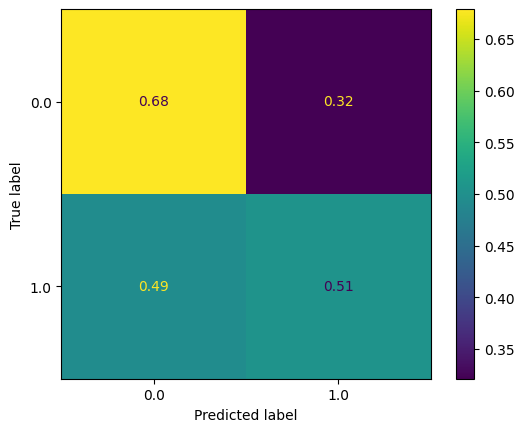

In [139]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, normalize='true')
plt.show()

In [140]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

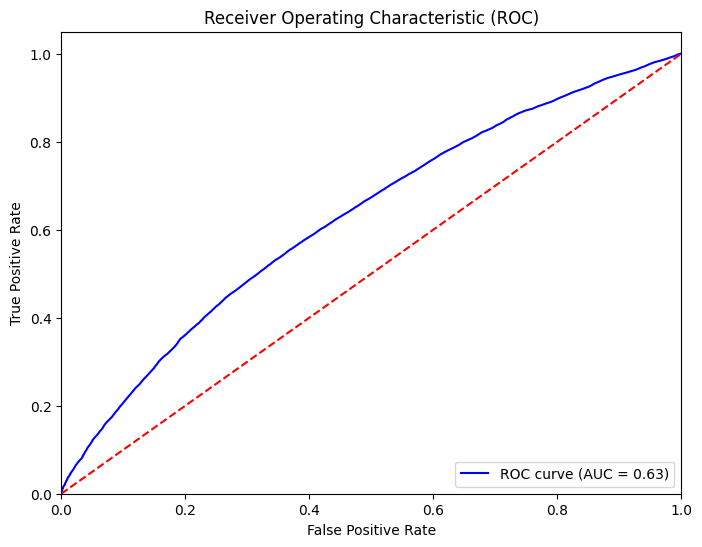

In [141]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [142]:
from imblearn.over_sampling import SMOTE

In [143]:
X_train_baseline = X_train.copy()
X_test_baseline = X_test.copy()
y_train_baseline = y_train.copy()
y_test_baseline = y_test.copy()

In [144]:
X_train_baseline.shape


(3581390, 58)

In [145]:
X_test_baseline.shape

(895348, 58)

In [146]:
X_train_baseline.duplicated().sum()

3050916

### Revisiting Feature Engineering

#### Numerical Data

#### SMOTE Only

In [147]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_smote_only, y_train_smote_only = sm.fit_resample(X_train_baseline, y_train_baseline)

# Train your model on X_train_sm, y_train_sm
model.fit(X_train_smote_only, y_train_smote_only)

# Evaluate on X_test (no transforms done)
y_pred_smote_only = model.predict(X_test_baseline)

In [148]:
y_proba_smote_only = model.predict_proba(X_test_baseline)[:, 1]

In [149]:
print(classification_report(y_test_baseline, y_pred_smote_only))

              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80    824726
         1.0       0.12      0.49      0.19     70622

    accuracy                           0.68    895348
   macro avg       0.53      0.59      0.50    895348
weighted avg       0.88      0.68      0.75    895348



In [150]:
auc_score = roc_auc_score(y_test_baseline, y_proba_smote_only)
print(f"ROC AUC: {auc_score:.3f}")

ROC AUC: 0.625


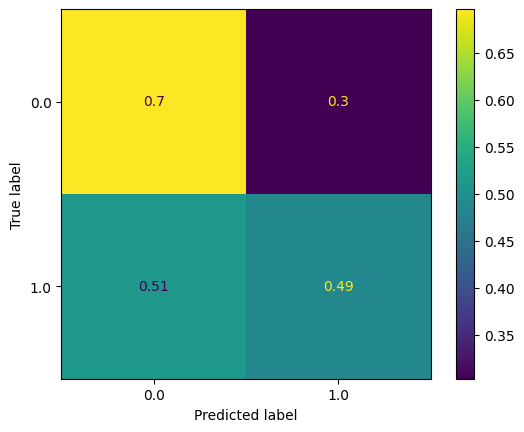

In [151]:
ConfusionMatrixDisplay.from_estimator(model, X_test_baseline, y_test_baseline, normalize='true')
plt.show()

## SOME + TRANSFORMATION

We need to discover which numerical columns need transformation. We create a list of all the columns that need it and the aplly the transformation.
The we do the SMOTE, then the FIT, then PREDICT.

In [152]:
X_train_baseline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3581390 entries, 3661429 to 1143694
Data columns (total 58 columns):
 #   Column                Dtype  
---  ------                -----  
 0   counter_coefficient   int64  
 1   consommation_level_1  int64  
 2   consommation_level_2  int64  
 3   consommation_level_3  int64  
 4   consommation_level_4  int64  
 5   difference_index      int64  
 6   disrict_62            float64
 7   disrict_63            float64
 8   disrict_69            float64
 9   client_catg_12        float64
 10  client_catg_51        float64
 11  region_103            float64
 12  region_104            float64
 13  region_105            float64
 14  region_106            float64
 15  region_107            float64
 16  region_199            float64
 17  region_206            float64
 18  region_301            float64
 19  region_302            float64
 20  region_303            float64
 21  region_304            float64
 22  region_305            float64
 23  region

In [ ]:
numerical_columns = ['counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'diference_index']

In [156]:
numerical_columns = ['counter_coefficient', 'consommation_level_1', 'consommation_level_2', 
                     'consommation_level_3', 'consommation_level_4', 'difference_index']

X_train_trans = X_train.copy()
for col in numerical_columns:
    # Example log transform, ensuring no negative or zero values
    X_train_trans[col] = np.log1p(X_train_trans[col].clip(lower=0))

In [158]:
sm = SMOTE(random_state=42)
X_train_trans_smote, y_train_trans_smote = sm.fit_resample(X_train_trans, y_train_baseline)